# QualiAR RJ — Unificação, Agregação e Normalização das Séries Diárias

Este notebook consolida e prepara as séries temporais de **qualidade do ar** e **variáveis meteorológicas** do **Rio de Janeiro (2012–2024)** 

## Objetivo
1. **Unificar** os CSVs diários das 8 estações do DataRio.
2. **Agregar por dia** para obter a **série municipal** (visão cidade).
3. **Avaliar e ajustar distribuições** (normalidade) por variável.
4. **Aplicar transformações** quando necessário (Yeo–Johnson) e **padronizar** as variáveis contínuas.

## Fontes e escopo
- **Estações**: BANGU, CAMPO_GRANDE, PEDRA_DE_GUARATIBA, IRAJA, SAO_CRISTOVAO, TIJUCA, CENTRO, COPACABANA.  
- **Variáveis**: `chuva, temp, ur, co, no, no2, nox, so2, o3, pm10, pm2_5, AQI` (+ `Qualidade_do_Ar` 1–5).  
- **Período**: 2012–2024.  

## Pipeline (resumo das etapas)
1. **Leitura e padronização**  
   - Normalização de nomes de colunas, conversão de `data_dia` para `datetime`.  
   - Inclusão de `nome_estacao` quando ausente.
2. **Unificação**  
   - Concatenação dos 8 CSVs em `df_estacoes` e remoção de duplicatas.
3. **Agregação municipal**  
   - `chuva`: **soma** entre estações.  
   - Variáveis contínuas e poluentes (incl. `AQI`): **média** entre estações.  
   - Gera `df_cidade` (uma linha por dia).
4. **Ajustes e colunas auxiliares**  
   - Arredondamento (3 casas), `AQI` inteiro, criação de `ano/mes/dia`.  
   - `Qualidade_do_Ar`: nível **numérico (1–5)** a partir do `AQI`.
5. **Análise de normalidade**  
   - Histograma + Q–Q e testes (Shapiro/K–S) **por coluna**.  
   - **Ex.:** `chuva` não normal (zero-inflada e cauda longa); `temp` e `ur` ~normais.
6. **Transformações e normalização**  
   - **Yeo–Johnson** aplicado **apenas** às variáveis não normais.  
   - `temp` e `ur`: **sem transformação** (já normais).  
   - `Qualidade_do_Ar` (1–5): **não é normalizada** (ordinal/derivada do `AQI`).  
   - **StandardScaler** aplicado às **contínuas** após as transformações.

## Decisões metodológicas importantes
- **Agregação antes** de testar normalidade/transformar (coerência com o alvo municipal).  
- **Yeo–Johnson** preferido a Box–Cox (lida com zeros/positivos).  
- **Sem normalizar `Qualidade_do_Ar`**; opcionalmente remover por redundância com `AQI`.  
- **Evitar vazamento**: ajustar transformações/escala **apenas no treino** e aplicar ao teste.


## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import os
import glob
import numpy as np
import unicodedata
import pandas as pd
import seaborn as sns
from scipy import stats
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path as _Path
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler 
from sklearn.preprocessing import PowerTransformer

OUT_BASE = Path(f"resultados_rio_de_janeiro")
FIG_DIR = OUT_BASE / "figuras"
DATA_DIR = OUT_BASE / "dados"
OUT_BASE.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = _Path(f"resultados_rio_de_janeiro") / "dados"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = _Path(f"resultados_rio_de_janeiro") / "figuras"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Helper para criar uma pasta por coluna 
def _col_dir(base_dir, col_name):
    safe = str(col_name).strip().lower().replace(" ", "_").replace("/", "_").replace("\\", "_")
    d = base_dir / safe
    d.mkdir(parents=True, exist_ok=True)
    return d

## Carregamento e Unificação das Estações

Nesta etapa:

1. Lemos os CSVs diários de cada estação diretamente do GitHub 
2. Garantimos que a coluna `data_dia` esteja no formato de data
3. Adicionamos o nome da estação quando não está no arquivo
4. Unimos todos os dados em um único DataFrame
5. Ordenamos por data e salvamos o resultado em `ESTACOES_UNIFICADAS_POR_DIA.csv`

In [3]:
def carregar_estacoes_github(estacoes):
    """
    Lê CSVs diretamente do repositório GitHub (modo raw) e concatena.
    
    estacoes: lista de nomes das estações (strings, ex.: ["BANGU", "CAMPO_GRANDE", ...])
    """
    base_url = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia"
    
    dfs = []
    for est in estacoes:
        url = f"{base_url}/ESTACAO_{est}_POR_DIA.csv"
        print(f"Lendo: {url}")
        df = pd.read_csv(url, encoding="utf-8")

        if "data_dia" in df.columns:
            df["data_dia"] = pd.to_datetime(df["data_dia"], errors="coerce")
       
        if "nome_estacao" not in df.columns:
            df["nome_estacao"] = est
        
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

lista_estacoes = ["BANGU", "CAMPO_GRANDE", "PEDRA_DE_GUARATIBA", "IRAJA", "SAO_CRISTOVAO", "TIJUCA", "CENTRO", "COPACABANA"]

df_estacoes = carregar_estacoes_github(lista_estacoes)

df_estacoes.sort_values(by=["data_dia"], inplace=True)

Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia/ESTACAO_BANGU_POR_DIA.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia/ESTACAO_CAMPO_GRANDE_POR_DIA.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia/ESTACAO_PEDRA_DE_GUARATIBA_POR_DIA.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia/ESTACAO_IRAJA_POR_DIA.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia/ESTACAO_SAO_CRISTOVAO_POR_DIA.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia/ESTACAO_TIJUCA_POR_DIA.csv
Lendo: https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/main/data/DataRio/Estacoes_Tratadas_Por_Dia/ESTACAO_CENTRO_POR_DIA.csv
Lendo: https://raw.githubusercon

In [4]:
project_root = Path().resolve().parents[2]  

output_dir = project_root / "data" / "DataRio" / "Estacoes_Tratadas_Por_Dia"
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / f"ESTACOES_UNIFICADAS_POR_DIA.csv"
df_estacoes.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\DataRio\Estacoes_Tratadas_Por_Dia\ESTACOES_UNIFICADAS_POR_DIA.csv


## Agregação das medições para toda a cidade do Rio de Janeiro

Nesta etapa:

1. Carregamos o arquivo **`ESTACOES_UNIFICADAS_POR_DIA.csv`** contendo as medições diárias de todas as estações.
2. Removemos colunas que não são necessárias para a agregação (`nome_estacao`, `codnum`, `ano`, `mes`, `dia`, `lat`, `lon`, `Qualidade_do_Ar`).
3. Agrupamos os dados pela coluna `data_dia`.
4. Calculamos a **média** de todas as variáveis numéricas para representar os valores diários médios do município.
5. O resultado é um DataFrame (`df_cidade`) com uma linha por dia e colunas contendo as variáveis atmosféricas e poluentes.


In [5]:
cols_to_drop = ["nome_estacao", "codnum", "ano", "mes", "dia", "lat", "lon", "Qualidade_do_Ar"]
df_estacoes = df_estacoes.drop(columns=[c for c in cols_to_drop if c in df_estacoes.columns])

df_estacoes["data_dia"] = pd.to_datetime(df_estacoes["data_dia"], errors="coerce")

df_cidade = df_estacoes.groupby("data_dia").mean(numeric_only=True).reset_index()

display(df_cidade.head())

,data_dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,temp_min,temp_max,AQI
0,2012-01-01,12.250,25.834571,92.165000,0.425833,3.613333,23.519667,27.129667,2.673333,23.059286,23.925143,14.619,24.027143,28.595714,17.0
1,2012-01-02,56.050,22.836286,95.588571,0.305333,12.675000,27.160333,39.842333,1.793833,20.136429,13.872000,5.083,21.670000,24.550000,13.0
2,2012-01-03,0.025,24.947875,76.139250,0.260143,17.175333,28.730667,45.882667,3.918500,15.718375,24.063625,4.208,20.225000,30.867500,19.0
3,2012-01-04,0.050,26.006250,72.904125,0.274571,24.745667,40.337667,65.049333,3.123667,25.002500,35.773375,15.729,22.196250,31.172500,34.0
4,2012-01-05,0.000,26.498125,75.514500,0.271286,16.643000,34.914000,51.558667,3.066000,33.646250,32.901000,10.917,21.993750,32.466250,37.0


In [6]:
for col in df_cidade.columns:
    if col not in ["data_dia", "AQI"]:
        df_cidade[col] = df_cidade[col].round(3)

if "AQI" in df_cidade.columns:
    df_cidade["AQI"] = df_cidade["AQI"].round(0).astype("Int64")

df_cidade["ano"] = df_cidade["data_dia"].dt.year
df_cidade["mes"] = df_cidade["data_dia"].dt.month
df_cidade["dia"] = df_cidade["data_dia"].dt.day

def qual_nivel(idx):
    if pd.isna(idx):
        return np.nan
    if 0 <= idx <= 40:
        return 1
    if 41 <= idx <= 80:
        return 2
    if 81 <= idx <= 120:
        return 3
    if 121 <= idx <= 200:
        return 4
    if 201 <= idx <= 400:
        return 5
    return np.nan

df_cidade["Qualidade_do_Ar"] = df_cidade["AQI"].apply(qual_nivel).astype("Int64")

cols = df_cidade.columns.tolist()

colunas_ordenadas = (
    ["data_dia", "ano", "mes", "dia"] +
    [c for c in cols if c not in ["data_dia", "ano", "mes", "dia"]]
)

df_cidade = df_cidade[colunas_ordenadas]

# Visualizar primeiras linhas
display(df_cidade.head())

,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,temp_min,temp_max,AQI,Qualidade_do_Ar
0,2012-01-01,2012,1,1,12.250,25.835,92.165,0.426,3.613,23.520,27.130,2.673,23.059,23.925,14.619,24.027,28.596,17,1
1,2012-01-02,2012,1,2,56.050,22.836,95.589,0.305,12.675,27.160,39.842,1.794,20.136,13.872,5.083,21.670,24.550,13,1
2,2012-01-03,2012,1,3,0.025,24.948,76.139,0.260,17.175,28.731,45.883,3.918,15.718,24.064,4.208,20.225,30.868,19,1
3,2012-01-04,2012,1,4,0.050,26.006,72.904,0.275,24.746,40.338,65.049,3.124,25.002,35.773,15.729,22.196,31.172,34,1
4,2012-01-05,2012,1,5,0.000,26.498,75.514,0.271,16.643,34.914,51.559,3.066,33.646,32.901,10.917,21.994,32.466,37,1


In [7]:
project_root = Path().resolve().parents[2]  

output_dir = project_root / "data" / "DataRio" 
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / f"QUALIAR_RIO_DE_JANEIRO.csv"
df_cidade.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\DataRio\QUALIAR_RIO_DE_JANEIRO.csv


## Inspeção inicial
Verificamos dimensões, tipos, amostras, faltantes e duplicados.

In [8]:
print("Dimensões:", df_cidade.shape)
print("\nTipos:")
print(df_cidade.dtypes)

print("\nAmostra:")
display(df_cidade.head())

print("\nValores ausentes por coluna:")
print(df_cidade.isna().sum())

# Duplicados (por carimbo horário e nome_estacao, se houver)
dup_cols = [c for c in ['data_dia'] if c in df_cidade.columns]
if dup_cols:
    ndup = df_cidade.duplicated(subset=dup_cols).sum()
    print(f"\nRegistros duplicados por {dup_cols}: {ndup}")
else:
    print("\nColunas para checar duplicados não disponíveis (nome_estacao/data).")

Dimensões: (4749, 19)

Tipos:
data_dia           datetime64[ns]
ano                         int32
mes                         int32
dia                         int32
chuva                     float64
temp                      float64
ur                        float64
co                        float64
no                        float64
no2                       float64
nox                       float64
so2                       float64
o3                        float64
pm10                      float64
pm2_5                     float64
temp_min                  float64
temp_max                  float64
AQI                         Int64
Qualidade_do_Ar             Int64
dtype: object

Amostra:


,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,temp_min,temp_max,AQI,Qualidade_do_Ar
0,2012-01-01,2012,1,1,12.250,25.835,92.165,0.426,3.613,23.520,27.130,2.673,23.059,23.925,14.619,24.027,28.596,17,1
1,2012-01-02,2012,1,2,56.050,22.836,95.589,0.305,12.675,27.160,39.842,1.794,20.136,13.872,5.083,21.670,24.550,13,1
2,2012-01-03,2012,1,3,0.025,24.948,76.139,0.260,17.175,28.731,45.883,3.918,15.718,24.064,4.208,20.225,30.868,19,1
3,2012-01-04,2012,1,4,0.050,26.006,72.904,0.275,24.746,40.338,65.049,3.124,25.002,35.773,15.729,22.196,31.172,34,1
4,2012-01-05,2012,1,5,0.000,26.498,75.514,0.271,16.643,34.914,51.559,3.066,33.646,32.901,10.917,21.994,32.466,37,1



Valores ausentes por coluna:
data_dia             0
ano                  0
mes                  0
dia                  0
chuva                0
temp                24
ur                  24
co                  26
no                  24
no2                 24
nox                 24
so2                261
o3                  23
pm10                23
pm2_5              478
temp_min            24
temp_max            24
AQI                 37
Qualidade_do_Ar     37
dtype: int64

Registros duplicados por ['data_dia']: 0


## Estatísticas descritivas por coluna

In [9]:
desc = df_cidade.describe(include='all').T
desc.to_csv(DATA_DIR / f"estatisticas_rio_de_janeiro.csv")
display(desc)

,count,mean,min,25%,50%,75%,max,std
data_dia,4749,2018-07-02 00:00:00.000000256,2012-01-01 00:00:00,2015-04-02 00:00:00,2018-07-02 00:00:00,2021-10-01 00:00:00,2024-12-31 00:00:00,NaN
ano,4749.0,2018.0,2012.0,2015.0,2018.0,2021.0,2024.0,3.742727
mes,4749.0,6.522215,1.0,4.0,7.0,10.0,12.0,3.449262
dia,4749.0,15.731733,1.0,8.0,16.0,23.0,31.0,8.801904
chuva,4749.0,3.115334,0.0,0.0,0.05,1.875,427.5,12.482548
temp,4725.0,26.008937,15.93,23.601,25.924,28.433,35.825,3.36198
ur,4725.0,71.588067,31.164,64.641,71.643,78.486,98.896,10.732352
co,4723.0,0.360048,0.081,0.269,0.338,0.418,1.475,0.13423
no,4725.0,13.950628,1.643,7.28,11.031,17.012,78.615,10.162804
no2,4725.0,32.660634,6.719,24.425,31.192,38.916,88.312,11.665142


## Séries temporais e médias móveis (7 e 30 dias)
Gera gráficos individuais por variável.

In [10]:
cols_to_analise = [c for c in ['chuva','temp','ur','co','no','no2','nox','so2','o3','pm10','pm2_5', 'AQI'] if c in df_cidade.columns]

In [11]:
def plot_series_with_roll(df_, col, outdir):
    if col not in df_.columns:
        return
    s = df_.set_index('data_dia')[col].sort_index()
    if s.dropna().empty:
        return
    rm7 = s.rolling('7D').mean()
    rm30 = s.rolling('30D').mean()

    plt.figure(figsize=(12,4))
    s.plot(linewidth=0.8, label=col)
    rm7.plot(linewidth=1.0, label='mm7')
    rm30.plot(linewidth=1.2, label='mm30')
    plt.title(f"{col} — Série horária e médias móveis")
    plt.xlabel("Tempo")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outdir / "serie.png", dpi=150)
    plt.close()

## Distribuições: histograma e boxplot

In [12]:
def plot_distributions(df_, col, outdir):
    if col not in df_.columns:
        return
    x = df_[col].dropna()
    if x.empty:
        return

    # Histograma
    plt.figure(figsize=(6,4))
    plt.hist(x, bins=40)
    plt.title(f"Histograma — {col}")
    plt.xlabel(col); plt.ylabel("Frequência")
    plt.tight_layout()
    plt.savefig(outdir / "hist.png", dpi=150)
    plt.close()

    # Boxplot
    plt.figure(figsize=(4,5))
    plt.boxplot(x.values, vert=True)
    plt.title(f"Boxplot — {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(outdir / "box.png", dpi=150)
    plt.close()


## Sazonalidade: perfis mensais e anuais

In [13]:
def monthly_profile(df_, col, outdir):
    if col not in df_.columns:
        return
    tmp = df_[['mes', col]].copy()
    g = tmp.groupby('mes')[col].mean(numeric_only=True)
    if g.dropna().empty:
        return
    plt.figure(figsize=(8,3.5))
    plt.plot(g.index, g.values, marker='o')
    plt.title(f"Média mensal — {col}")
    plt.xlabel("Mês"); plt.ylabel(col)
    plt.xticks(range(1,13))
    plt.tight_layout()
    plt.savefig(outdir / "mensal.png", dpi=150)
    plt.close()

def yearly_profile(df_, col, outdir):
    if col not in df_.columns:
        return
    tmp = df_[['ano', col]].copy()
    g = tmp.groupby('ano')[col].mean(numeric_only=True)
    if g.dropna().empty:
        return
    plt.figure(figsize=(8,3.5))
    plt.plot(g.index, g.values, marker='o')
    plt.title(f"Média anual — {col}")
    plt.xlabel("Ano"); plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(outdir / "anual.png", dpi=150)
    plt.close()


## Gerando figuras

In [14]:
for c in cols_to_analise:
    col_dir = _col_dir(FIG_DIR, c)
    plot_series_with_roll(df_cidade, c, col_dir)
    plot_distributions(df_cidade, c, col_dir)
    monthly_profile(df_cidade, c, col_dir)
    yearly_profile(df_cidade, c, col_dir)

print("Figuras salvas por coluna em subpastas de:", FIG_DIR)

Figuras salvas por coluna em subpastas de: resultados_rio_de_janeiro\figuras


## Teste de normalidade por coluna (Histograma + Q–Q) e Shapiro/K–S

Use a função `plot_normalidade(df, "nome_da_coluna")` para:
- Plotar **histograma** e **Q–Q plot** lado a lado.
- Exibir **Shapiro–Wilk** e **Kolmogorov–Smirnov** (K–S) abaixo dos gráficos.

> Obs.: O K–S é feito contra Normal **com média e desvio-padrão estimados** a partir da amostra.


In [15]:
def plot_hist_qq(df: pd.DataFrame, col: str, bins: int = 100, unit: str = "", figsize=(14, 7)):
    """
    Plota (lado a lado):
      - Histograma estilizado com KDE, linhas de média e mediana, e caixa com estatísticas.
      - Q–Q plot contra Normal.
    """
    x = pd.to_numeric(df[col], errors="coerce").dropna().values
    n = x.size
    if n < 3:
        raise ValueError(f"Coluna '{col}' tem dados insuficientes (n={n}).")

    mu = float(np.mean(x))
    sigma = float(np.std(x, ddof=1)) if n > 1 else 0.0
    median_val = float(np.median(x))
    max_val = float(np.max(x))
    unit_suf = f" ({unit})" if unit else ""

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Histograma + KDE
    ax = sns.histplot(x=x, kde=True, bins=bins, stat="density", ax=axes[0])
    axes[0].set_title(f"Distribuição de {col}", fontsize=18, pad=16, fontweight="bold")
    axes[0].set_xlabel(f"{col}{unit_suf}", fontsize=13, labelpad=8)
    axes[0].set_ylabel("Densidade de probabilidade", fontsize=13, labelpad=8)
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)
    axes[0].set_axisbelow(True)

    # Linhas de média e mediana
    axes[0].axvline(mu, linestyle="--", color='#ff7f0e', linewidth=2.2, label=f"Média: {mu:.2f}{(' ' + unit) if unit else ''}")
    axes[0].axvline(median_val, color='#2ca02c', linestyle="--", linewidth=2.2, label=f"Mediana: {median_val:.2f}{(' ' + unit) if unit else ''}")
    axes[0].legend(fontsize=11, framealpha=0.9, loc="best")

    # Caixa com estatísticas
    stats_text = (
        f"Estatísticas:\n"
        f"- n: {n}\n"
        f"- Média: {mu:.2f} {unit}\n"
        f"- Mediana: {median_val:.2f} {unit}\n"
        f"- Std: {sigma:.2f}\n"
        f"- Máx: {max_val:.2f} {unit}"
    ).replace("  ", " ")
    axes[0].text(
        0.98, 0.75, stats_text, transform=axes[0].transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
    )

    # Q–Q plot
    stats.probplot(x, dist="norm", plot=axes[1])
    axes[1].set_title(f"Q–Q plot – {col}", fontsize=16, pad=10)
    axes[1].set_xlabel("Quantis teóricos (Normal)", fontsize=12)
    axes[1].set_ylabel("Quantis observados", fontsize=12)

    plt.tight_layout()
    plt.show()


def print_normality_tests(df: pd.DataFrame, col: str, sample_size: int = 1000, seed: int | None = 40):
    """
    Executa os testes de Shapiro–Wilk e Kolmogorov–Smirnov contra Normal(μ, σ) e PRINTA os resultados.
    - Usa amostra aleatória sem reposição de tamanho `sample_size` (ou todos os dados se n <= sample_size).
    - Mantém o formato de mensagens solicitado.
    """
    x_full = pd.to_numeric(df[col], errors="coerce").dropna().values
    n = x_full.size
    if n < 3:
        raise ValueError(f"Coluna '{col}' tem dados insuficientes (n={n}).")

    if (sample_size is not None) and (n > sample_size):
        rng = np.random.default_rng(seed)
        random_sample = rng.choice(x_full, size=sample_size, replace=False)
    else:
        random_sample = x_full

    # --- Shapiro–Wilk ---
    stat, p_value = stats.shapiro(random_sample)
    print(f"Teste de Shapiro para {col}: Estatística = {stat:.3f}, p-valor = {p_value:.3f}")
    if p_value > 0.05:
        print(f"{col} parece seguir uma distribuição normal (p > 0.05).")
    else:
        print(f"{col} NÃO segue uma distribuição normal (p <= 0.05).")
    print(f"p_value gerado: {p_value}")

    # --- Kolmogorov–Smirnov (contra Normal(μ, σ) da amostra) ---
    mu = float(np.mean(random_sample))
    sigma = float(np.std(random_sample, ddof=1)) if random_sample.size > 1 else 0.0

    if sigma <= 0 or np.isnan(sigma):
        print("\nTeste de Kolmogorov-Smirnov: não aplicável (desvio-padrão inválido).")
        print("p_value gerado: n/d")
        return

    stat, p_value = stats.kstest(random_sample, 'norm', args=(mu, sigma))
    print(f"\nTeste de Kolmogorov-Smirnov: Estatística = {stat:.3f}, p-valor = {p_value:.3f}")
    if p_value > 0.05:
        print("A amostra parece seguir uma distribuição normal.")
    else:
        print("A amostra NÃO segue uma distribuição normal.")
    print(f"p_value gerado: {p_value}")


### Chuva

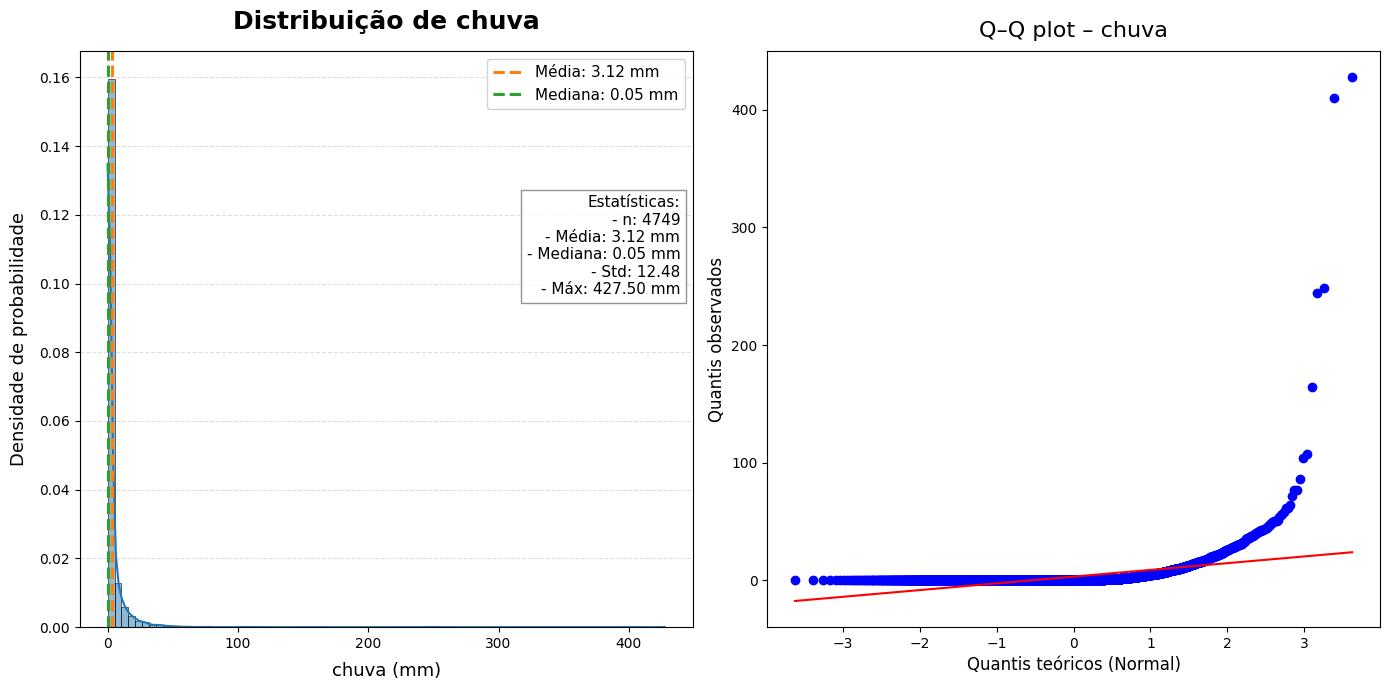

Teste de Shapiro para chuva: Estatística = 0.281, p-valor = 0.000
chuva NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 3.862404212717188e-52

Teste de Kolmogorov-Smirnov: Estatística = 0.385, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 1.0101719944026433e-133


In [23]:
plot_hist_qq(df_cidade, "chuva", bins=80, unit="mm")
print_normality_tests(df_cidade, "chuva", sample_size=1000, seed=40)

In [24]:
df_cidade["chuva"] = pd.to_numeric(df_cidade["chuva"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["chuva"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
chuva_vals = df_cidade.loc[mask, ["chuva"]].values  
df_cidade.loc[mask, "chuva_yj"] = pt.fit_transform(chuva_vals).ravel()

lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'chuva' com lambda = {lambda_yj:.6f}")

print(df_cidade[["chuva", "chuva_yj"]].head())

Yeo–Johnson aplicado em 'chuva' com lambda = -1.109588
    chuva  chuva_yj
0  12.250  0.849992
1  56.050  0.891094
2   0.025  0.024357
3   0.050  0.047493
4   0.000 -0.000000


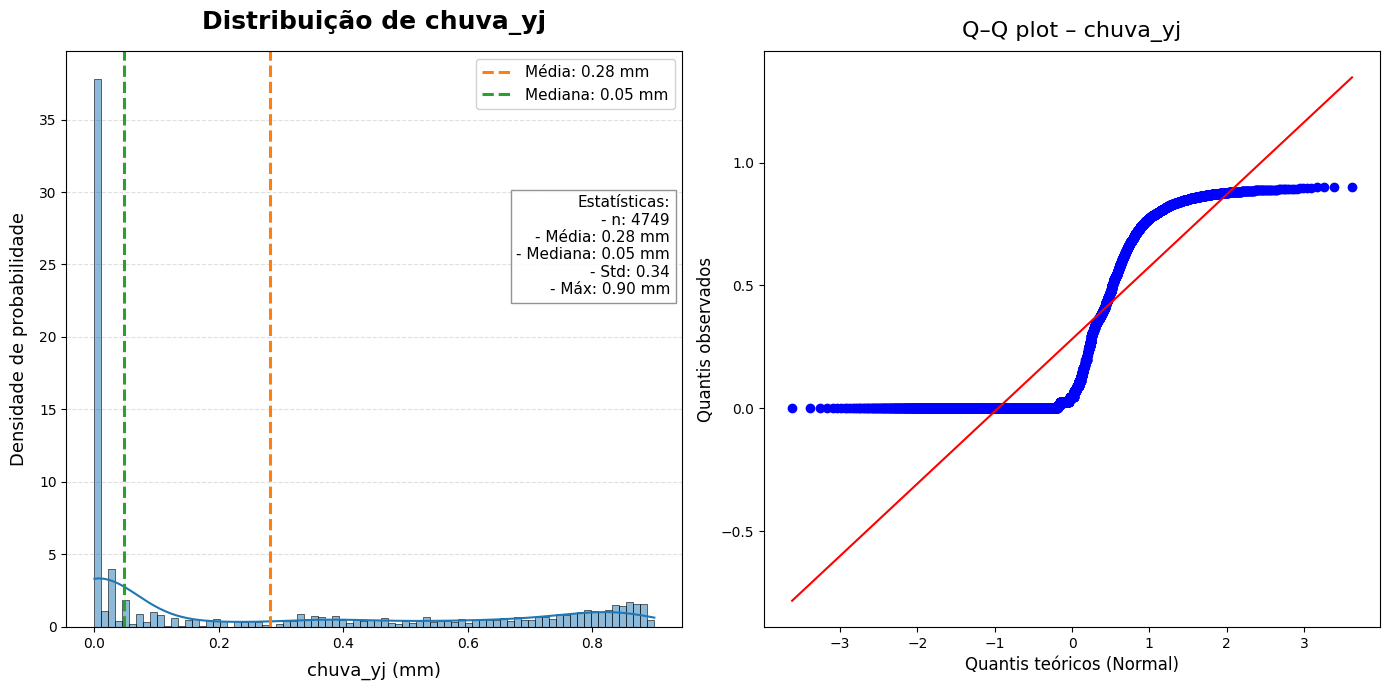

Teste de Shapiro para chuva_yj: Estatística = 0.756, p-valor = 0.000
chuva_yj NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 5.298513203169285e-36

Teste de Kolmogorov-Smirnov: Estatística = 0.275, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 3.475808939770839e-67


In [25]:
plot_hist_qq(df_cidade, "chuva_yj", bins=80, unit="mm")
print_normality_tests(df_cidade, "chuva_yj", sample_size=1000, seed=40)

### Tempratura

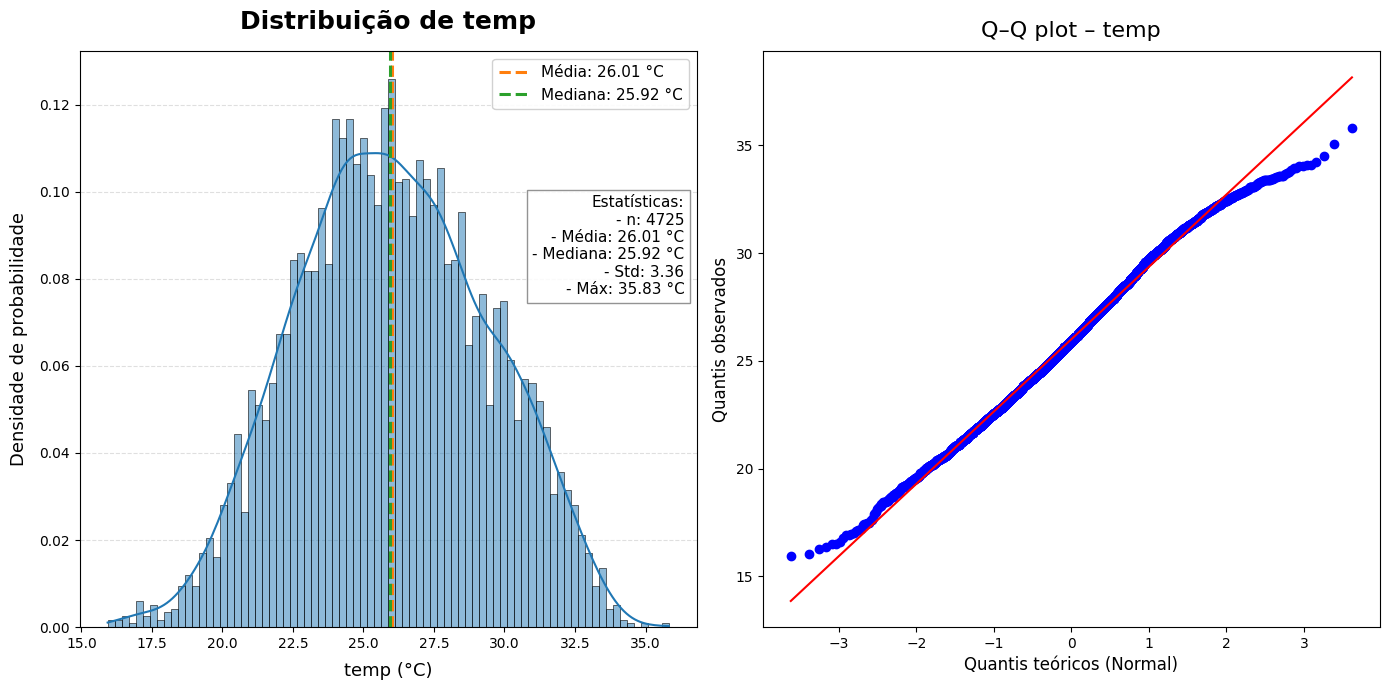

Teste de Shapiro para temp: Estatística = 0.995, p-valor = 0.002
temp NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 0.0021053993464330437

Teste de Kolmogorov-Smirnov: Estatística = 0.025, p-valor = 0.570
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.5702916494938153


In [26]:
plot_hist_qq(df_cidade, "temp", bins=80, unit="°C")
print_normality_tests(df_cidade, "temp", sample_size=1000, seed=40)

### Tempratura minima

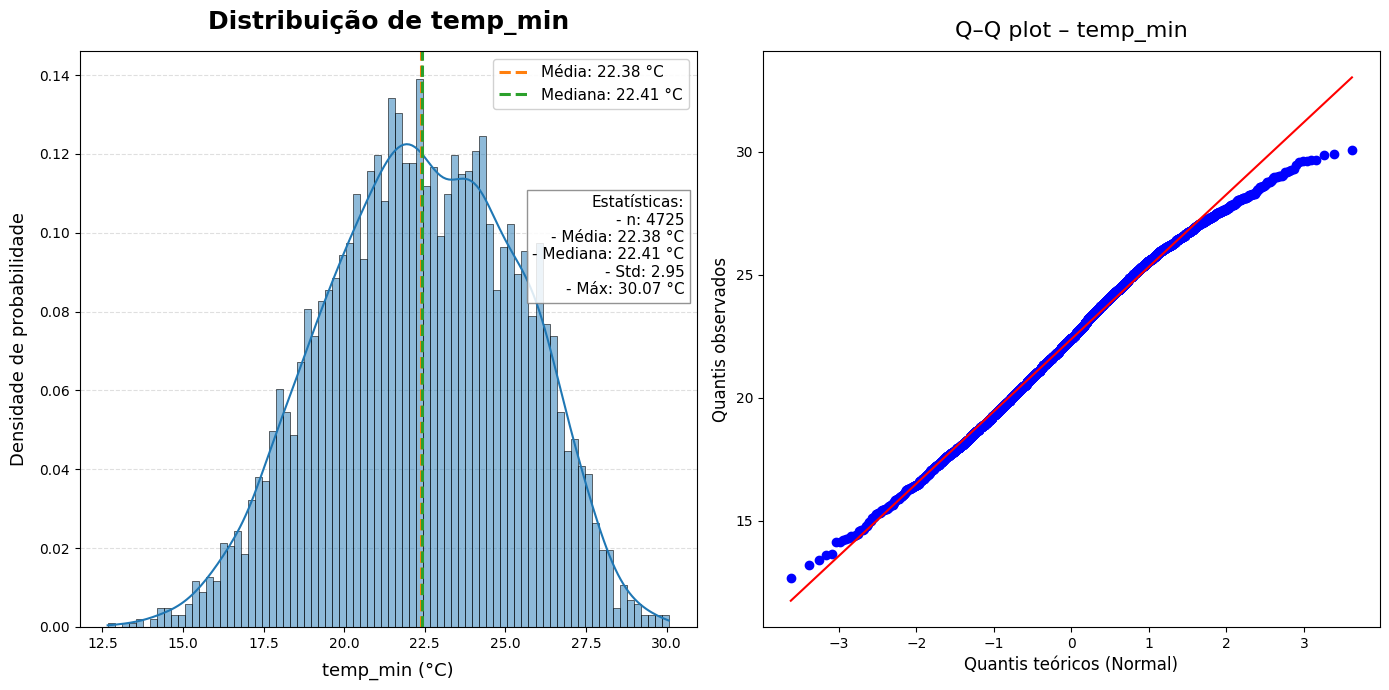

Teste de Shapiro para temp_min: Estatística = 0.993, p-valor = 0.000
temp_min NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 0.00020930809087947428

Teste de Kolmogorov-Smirnov: Estatística = 0.035, p-valor = 0.177
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.1773120036528355


In [27]:
plot_hist_qq(df_cidade, "temp_min", bins=80, unit="°C")
print_normality_tests(df_cidade, "temp_min", sample_size=1000, seed=40)

### Tempratura máxima

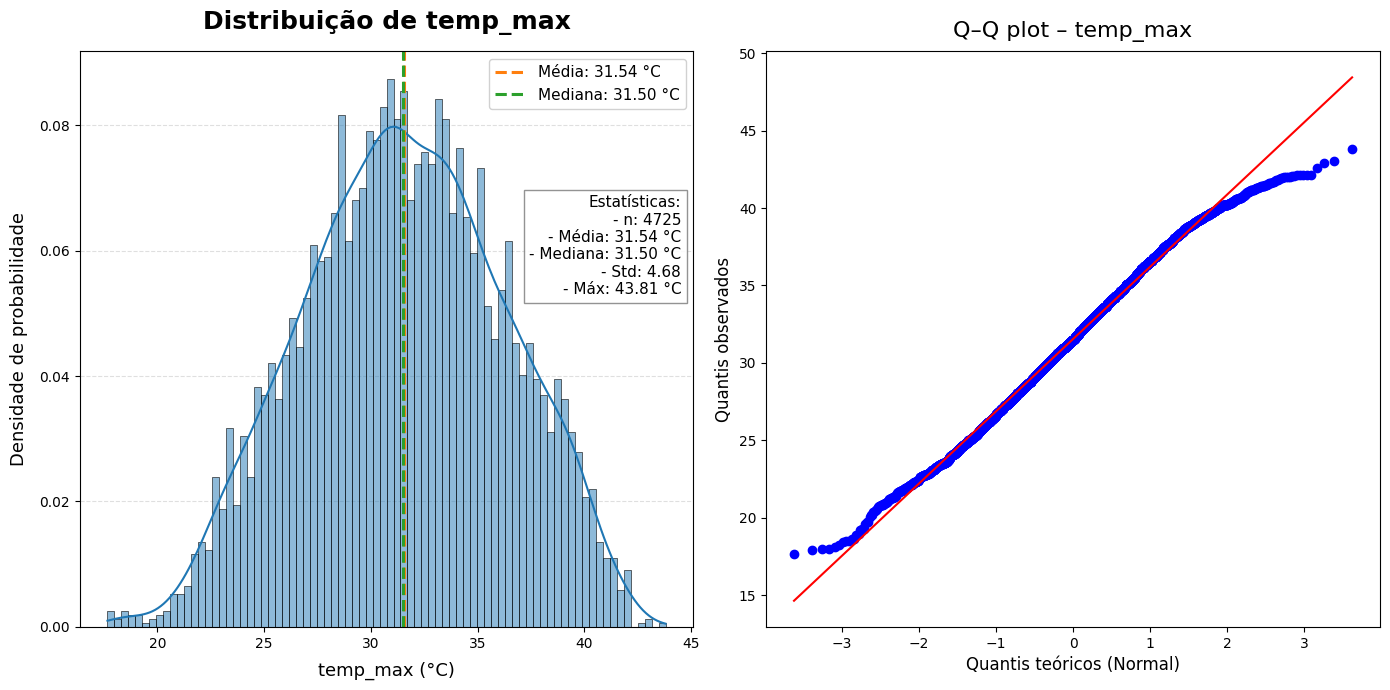

Teste de Shapiro para temp_max: Estatística = 0.995, p-valor = 0.003
temp_max NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 0.003010291878001235

Teste de Kolmogorov-Smirnov: Estatística = 0.020, p-valor = 0.799
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.7986818230648732


In [28]:
plot_hist_qq(df_cidade, "temp_max", bins=80, unit="°C")
print_normality_tests(df_cidade, "temp_max", sample_size=1000, seed=40)

### Umidade Relativa

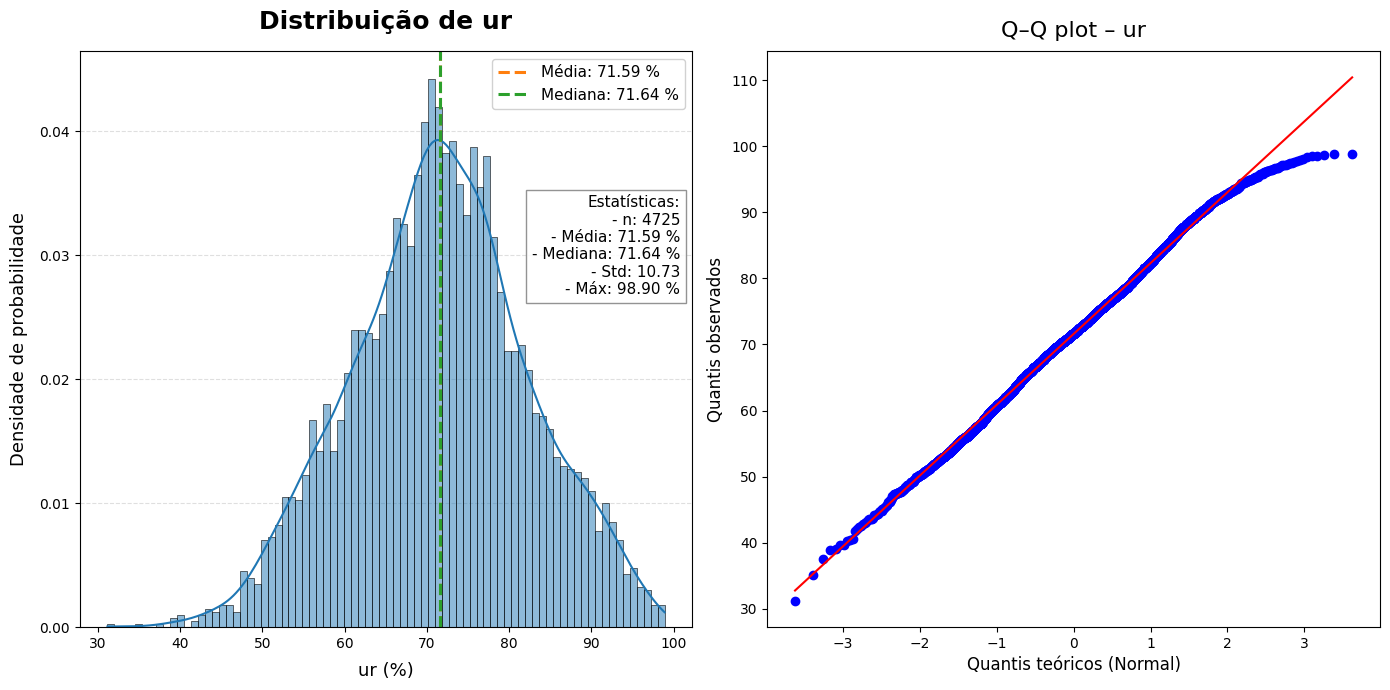

Teste de Shapiro para ur: Estatística = 0.997, p-valor = 0.034
ur NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 0.0336587610331769

Teste de Kolmogorov-Smirnov: Estatística = 0.020, p-valor = 0.815
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.8147062774974589


In [29]:
plot_hist_qq(df_cidade, "ur", bins=80, unit="%")
print_normality_tests(df_cidade, "ur", sample_size=1000, seed=40)

### AQI

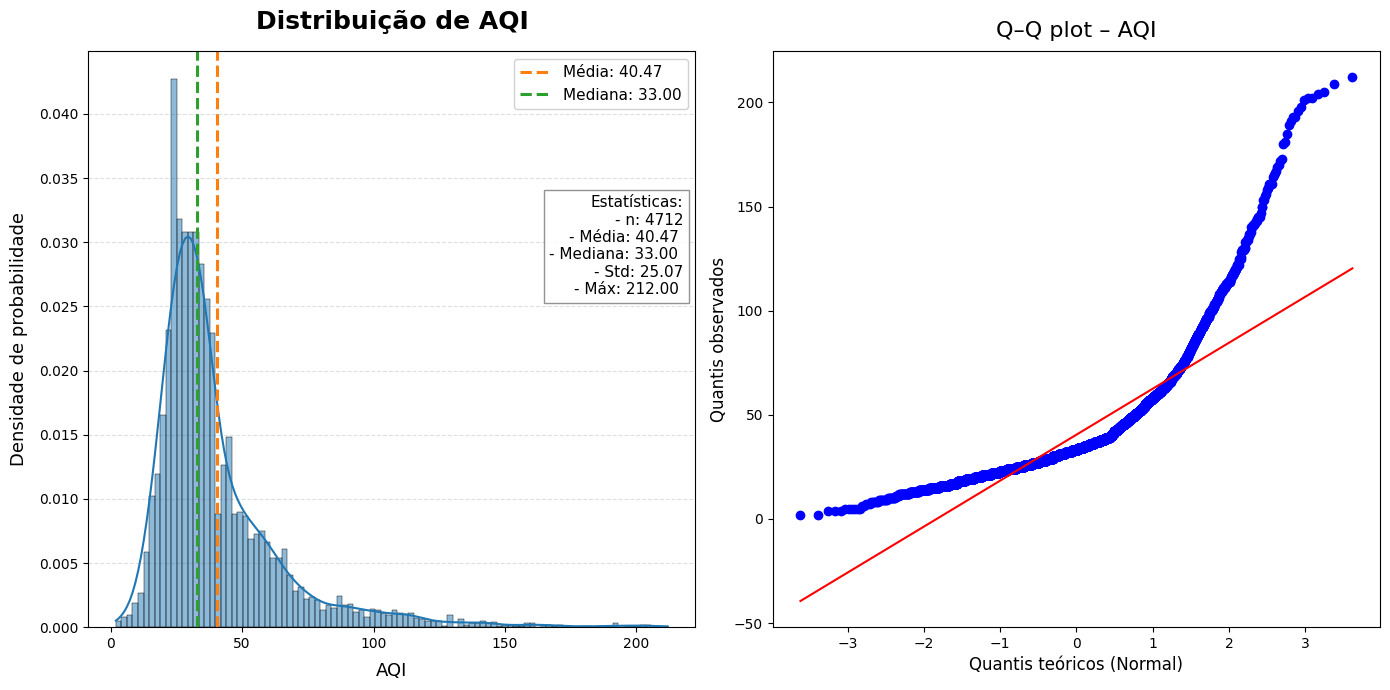

Teste de Shapiro para AQI: Estatística = 0.784, p-valor = 0.000
AQI NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 2.21483286630194e-34

Teste de Kolmogorov-Smirnov: Estatística = 0.193, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 4.55422946318227e-33


In [30]:
plot_hist_qq(df_cidade, "AQI", bins=100)
print_normality_tests(df_cidade, "AQI", sample_size=1000, seed=40)

In [31]:
df_cidade["AQI"] = pd.to_numeric(df_cidade["AQI"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["AQI"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
AQI_vals = df_cidade.loc[mask, ["AQI"]].values  
df_cidade.loc[mask, "AQI_yj"] = pt.fit_transform(AQI_vals).ravel()

lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'AQI' com lambda = {lambda_yj:.6f}")

print(df_cidade[["AQI", "AQI_yj"]].head())

Yeo–Johnson aplicado em 'AQI' com lambda = -0.182001
   AQI    AQI_yj
0   17  2.247600
1   13  2.095642
2   19  2.309268
3   34  2.617709
4   37  2.660446


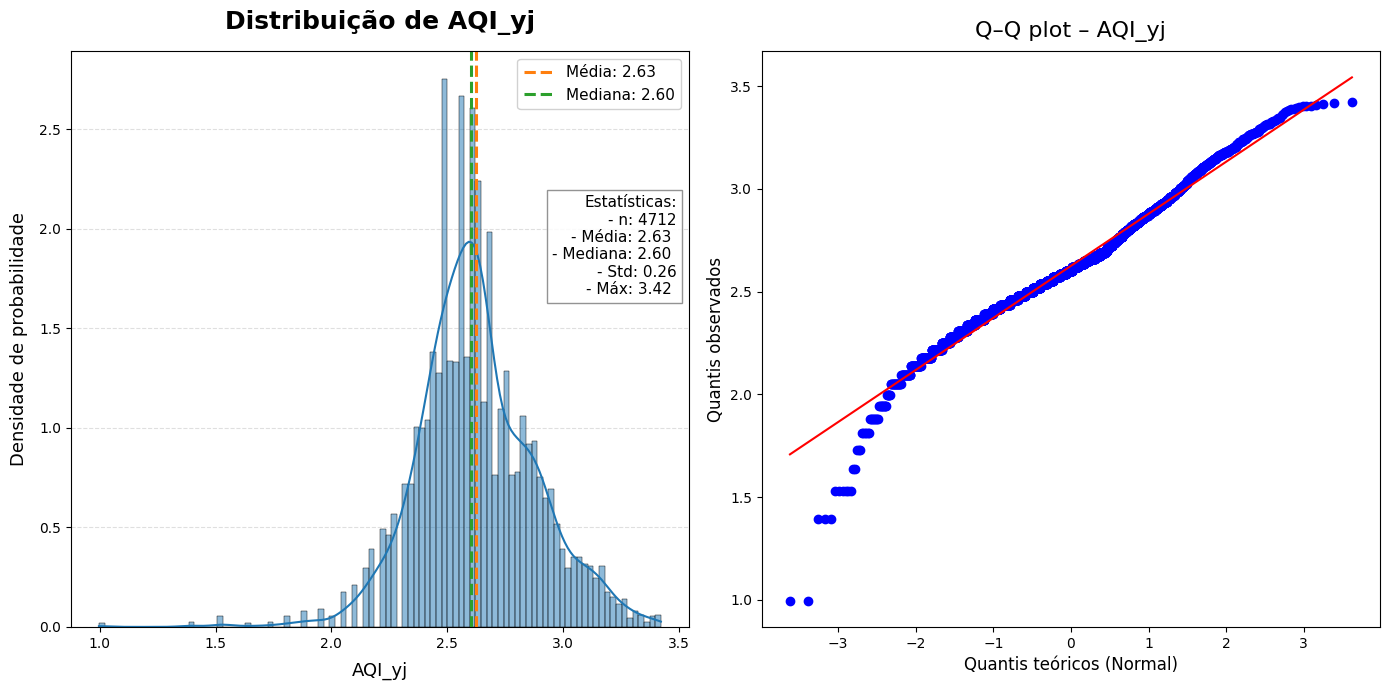

Teste de Shapiro para AQI_yj: Estatística = 0.978, p-valor = 0.000
AQI_yj NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 3.4207219179407844e-11

Teste de Kolmogorov-Smirnov: Estatística = 0.075, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 2.7018837921594944e-05


In [32]:
plot_hist_qq(df_cidade, "AQI_yj", bins=100)
print_normality_tests(df_cidade, "AQI_yj", sample_size=1000, seed=40)

### Monóxido de carbono

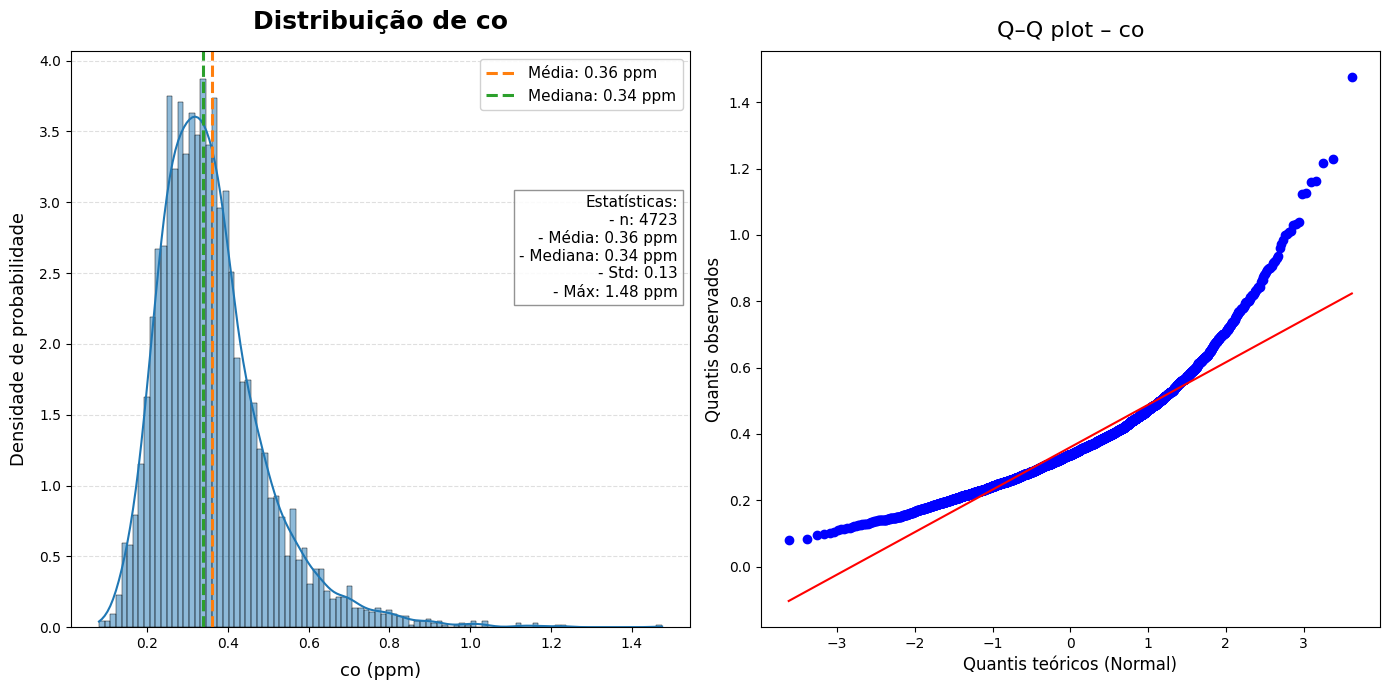

Teste de Shapiro para co: Estatística = 0.912, p-valor = 0.000
co NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 1.2096089535103817e-23

Teste de Kolmogorov-Smirnov: Estatística = 0.095, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 3.0032632347429155e-08


In [33]:
plot_hist_qq(df_cidade, "co", bins=100, unit="ppm")
print_normality_tests(df_cidade, "co", sample_size=1000, seed=40)

In [34]:
df_cidade["co"] = pd.to_numeric(df_cidade["co"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["co"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
co_vals = df_cidade.loc[mask, ["co"]].values 
df_cidade.loc[mask, "co_yj"] = pt.fit_transform(co_vals).ravel()

lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'co' com lambda = {lambda_yj:.6f}")

print(df_cidade[["co", "co_yj"]].head())

Yeo–Johnson aplicado em 'co' com lambda = -3.084435
      co     co_yj
0  0.426  0.215703
1  0.305  0.181572
2  0.260  0.165267
3  0.275  0.170964
4  0.271  0.169471


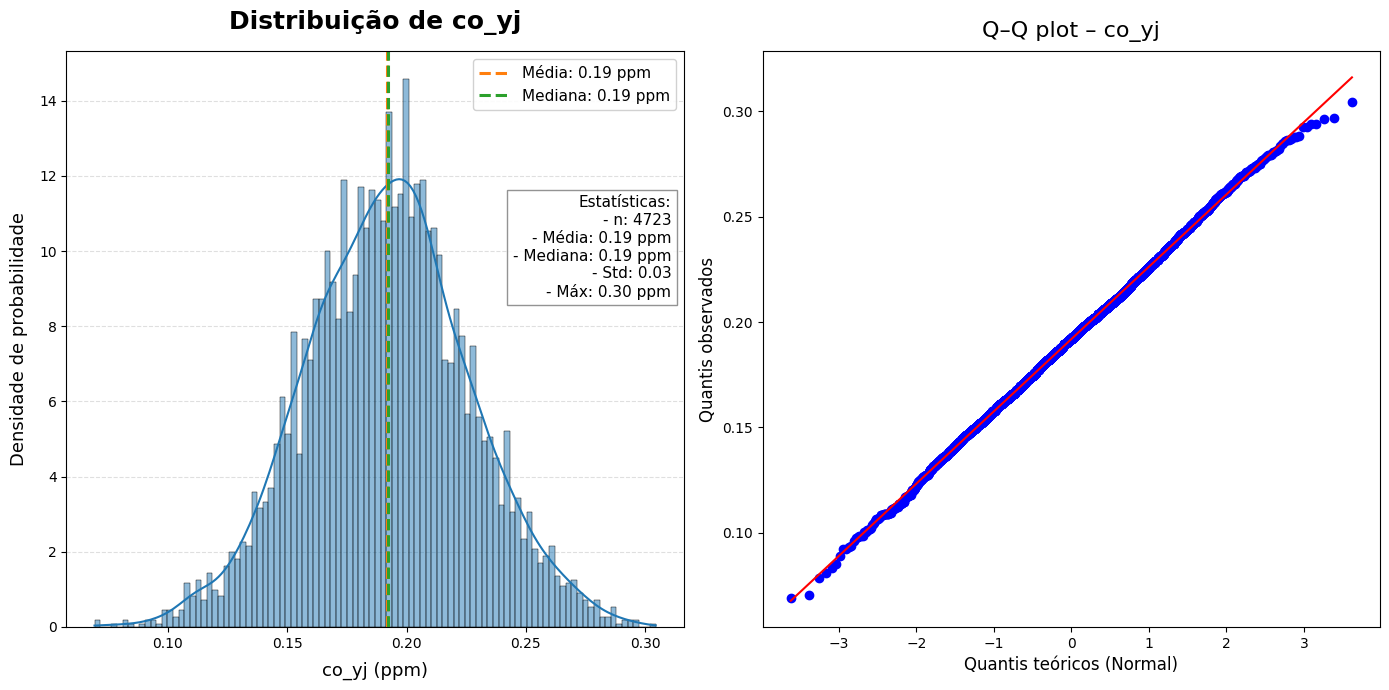

Teste de Shapiro para co_yj: Estatística = 0.999, p-valor = 0.628
co_yj parece seguir uma distribuição normal (p > 0.05).
p_value gerado: 0.6283082681834053

Teste de Kolmogorov-Smirnov: Estatística = 0.021, p-valor = 0.746
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.7464909931943976


In [35]:
plot_hist_qq(df_cidade, "co_yj", bins=100, unit="ppm")
print_normality_tests(df_cidade, "co_yj", sample_size=1000, seed=40)

### Monóxido de nitrogênio

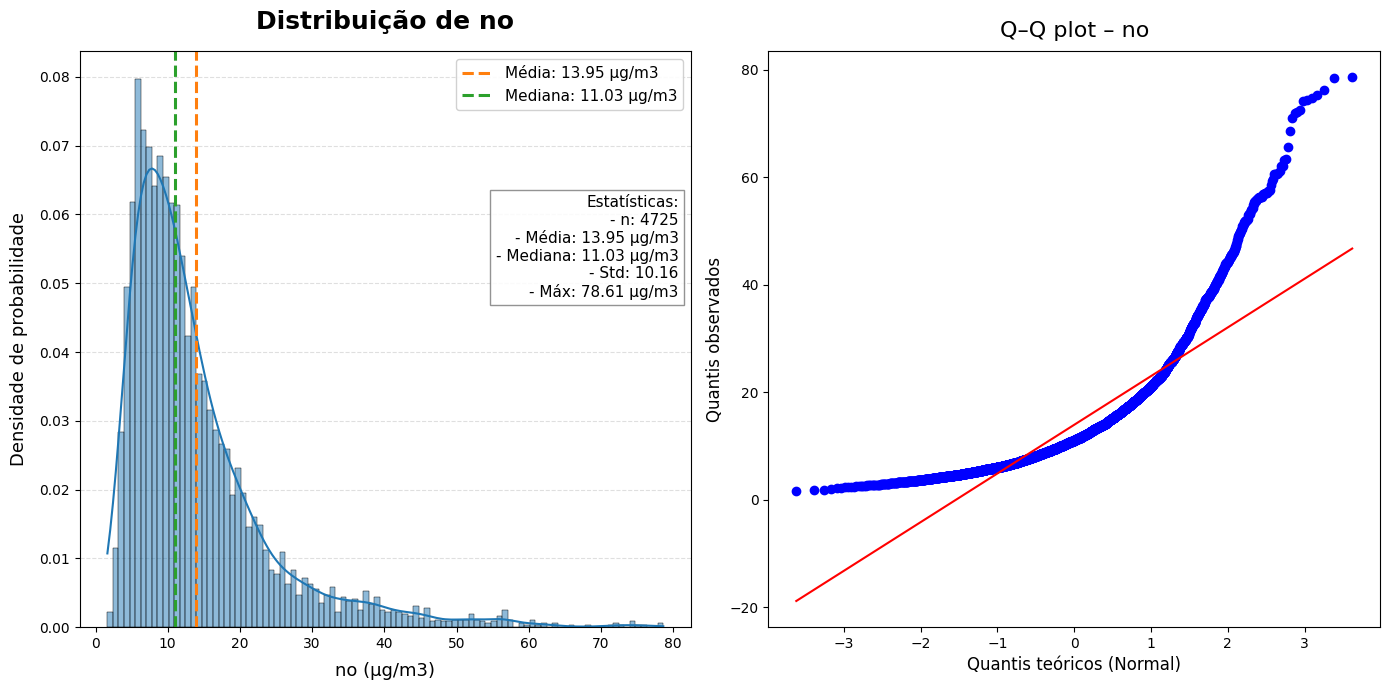

Teste de Shapiro para no: Estatística = 0.790, p-valor = 0.000
no NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 5.059721699220909e-34

Teste de Kolmogorov-Smirnov: Estatística = 0.168, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 3.004571386570644e-25


In [36]:
plot_hist_qq(df_cidade, "no", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "no", sample_size=1000, seed=40)

In [37]:
df_cidade["no"] = pd.to_numeric(df_cidade["no"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["no"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
no_vals = df_cidade.loc[mask, ["no"]].values  
df_cidade.loc[mask, "no_yj"] = pt.fit_transform(no_vals).ravel()

lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'no' com lambda = {lambda_yj:.6f}")

print(df_cidade[["no", "no_yj"]].head())

Yeo–Johnson aplicado em 'no' com lambda = -0.265990
       no     no_yj
0   3.613  1.256189
1  12.675  1.884591
2  17.175  2.021231
3  24.746  2.175012
4  16.643  2.007440


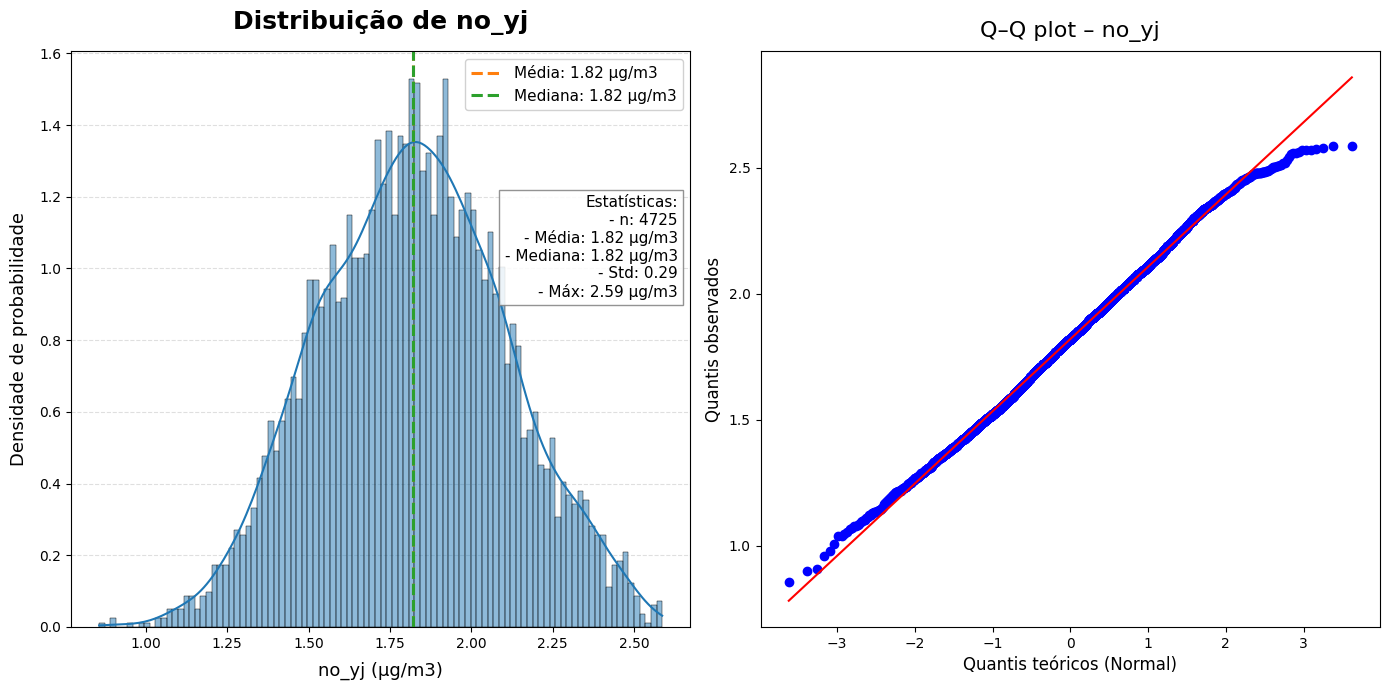

Teste de Shapiro para no_yj: Estatística = 0.996, p-valor = 0.014
no_yj NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 0.01377201562026832

Teste de Kolmogorov-Smirnov: Estatística = 0.025, p-valor = 0.548
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.5475323516433174


In [38]:
plot_hist_qq(df_cidade, "no_yj", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "no_yj", sample_size=1000, seed=40)

### Dióxido de nitrogênio

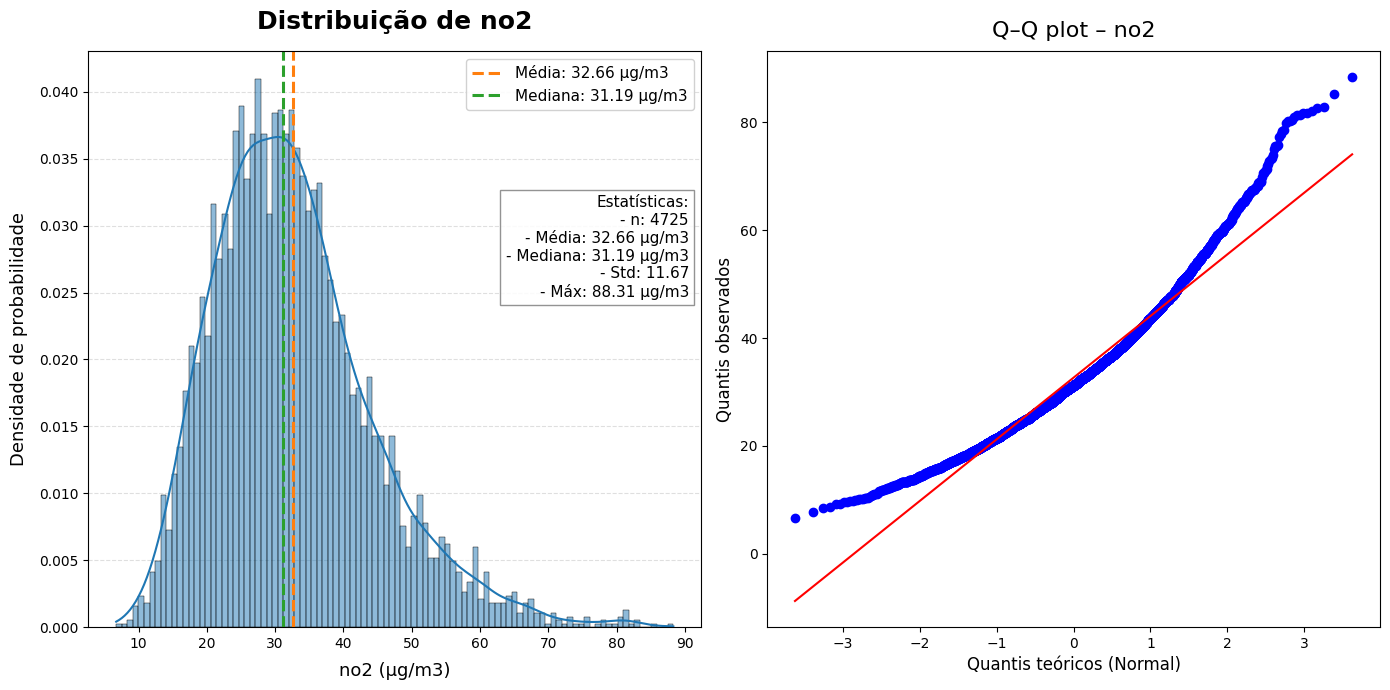

Teste de Shapiro para no2: Estatística = 0.952, p-valor = 0.000
no2 NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 1.3845680693277416e-17

Teste de Kolmogorov-Smirnov: Estatística = 0.068, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 0.00018936274731845215


In [39]:
plot_hist_qq(df_cidade, "no2", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "no2", sample_size=1000, seed=40)

In [40]:
df_cidade["no2"] = pd.to_numeric(df_cidade["no2"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["no2"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
no2_vals = df_cidade.loc[mask, ["no2"]].values 
df_cidade.loc[mask, "no2_yj"] = pt.fit_transform(no2_vals).ravel()

lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'no2' com lambda = {lambda_yj:.6f}")

print(df_cidade[["no2", "no2_yj"]].head())

Yeo–Johnson aplicado em 'no2' com lambda = 0.160929
      no2    no2_yj
0  23.520  4.184802
1  27.160  4.419030
2  28.731  4.512331
3  40.338  5.096621
4  34.914  4.843477


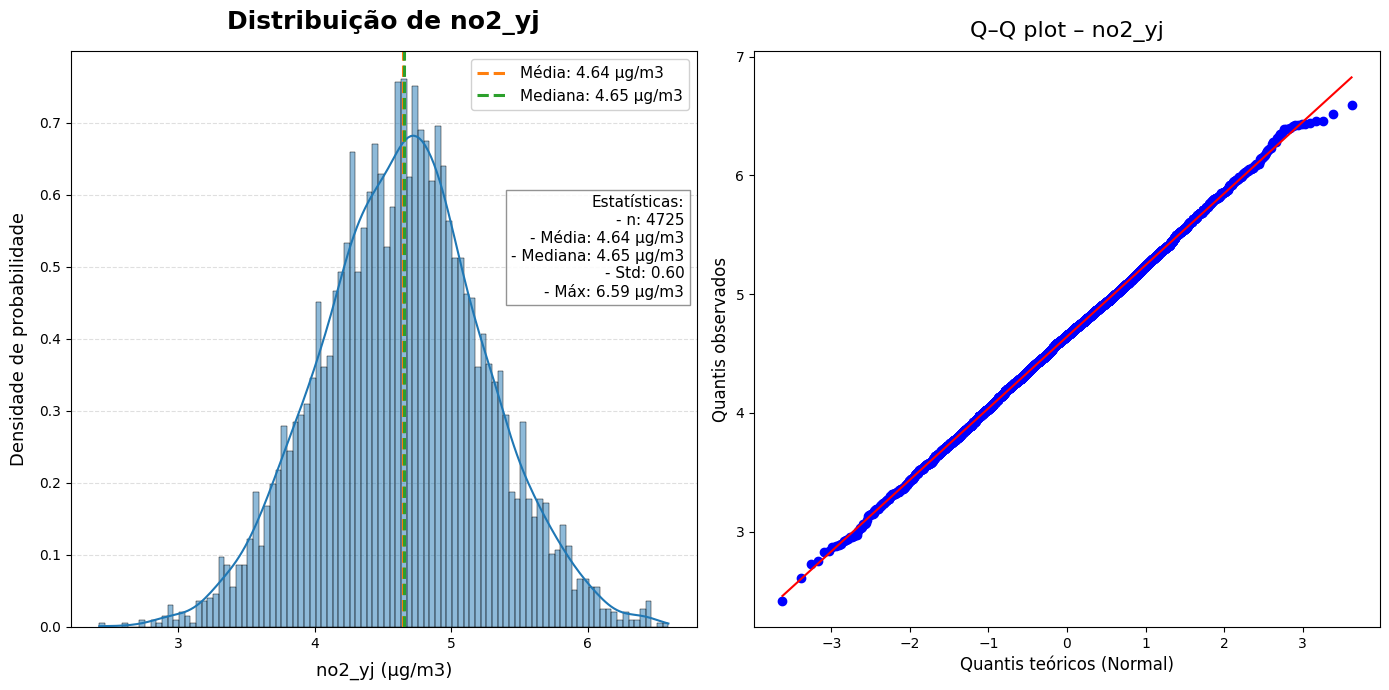

Teste de Shapiro para no2_yj: Estatística = 0.999, p-valor = 0.572
no2_yj parece seguir uma distribuição normal (p > 0.05).
p_value gerado: 0.5716520622223008

Teste de Kolmogorov-Smirnov: Estatística = 0.014, p-valor = 0.985
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.9845667562562673


In [41]:
plot_hist_qq(df_cidade, "no2_yj", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "no2_yj", sample_size=1000, seed=40)

### Óxido de nitrogênio

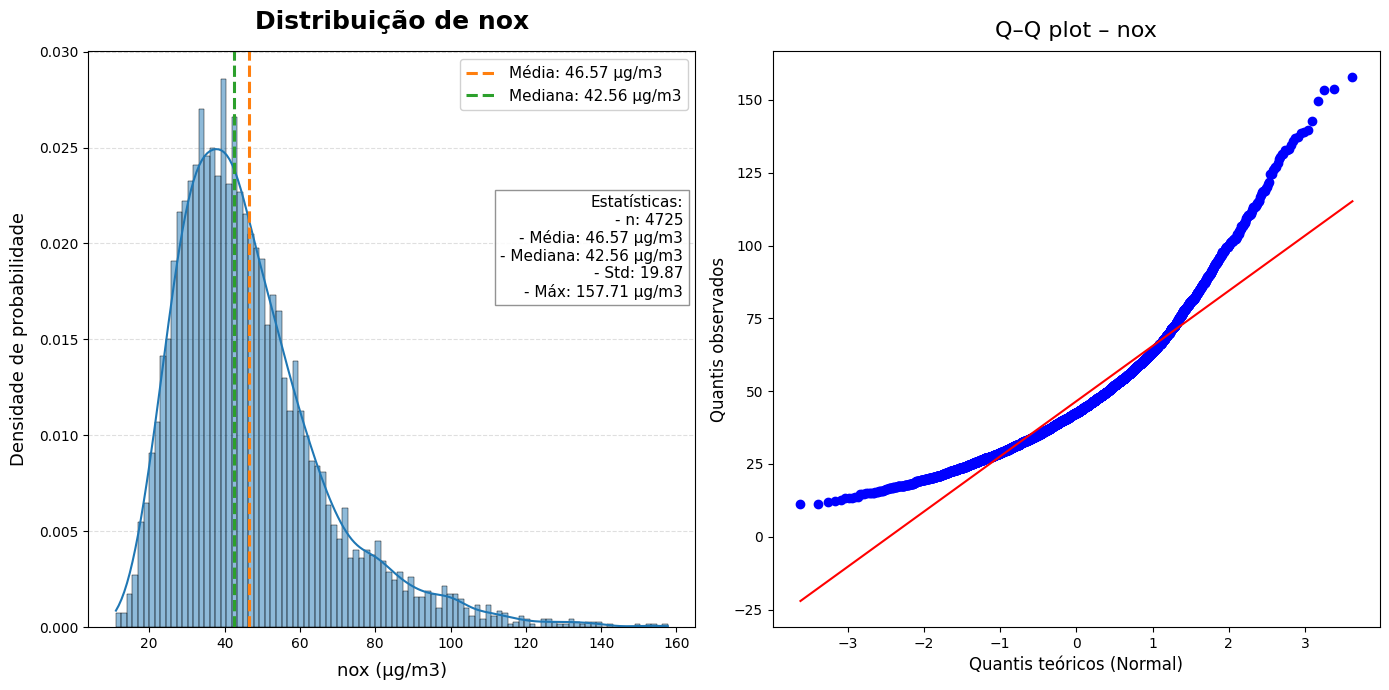

Teste de Shapiro para nox: Estatística = 0.900, p-valor = 0.000
nox NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 5.5398521203855895e-25

Teste de Kolmogorov-Smirnov: Estatística = 0.102, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 1.9609811994516975e-09


In [42]:
plot_hist_qq(df_cidade, "nox", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "nox", sample_size=1000, seed=40)

In [43]:
df_cidade["nox"] = pd.to_numeric(df_cidade["nox"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["nox"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
nox_vals = df_cidade.loc[mask, ["nox"]].values 
df_cidade.loc[mask, "nox_yj"] = pt.fit_transform(nox_vals).ravel()

lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'nox' com lambda = {lambda_yj:.6f}")

print(df_cidade[["nox", "nox_yj"]].head())

Yeo–Johnson aplicado em 'nox' com lambda = -0.115160
      nox    nox_yj
0  27.130  2.770516
1  39.842  3.019050
2  45.883  3.108324
3  65.049  3.324094
4  51.559  3.181217


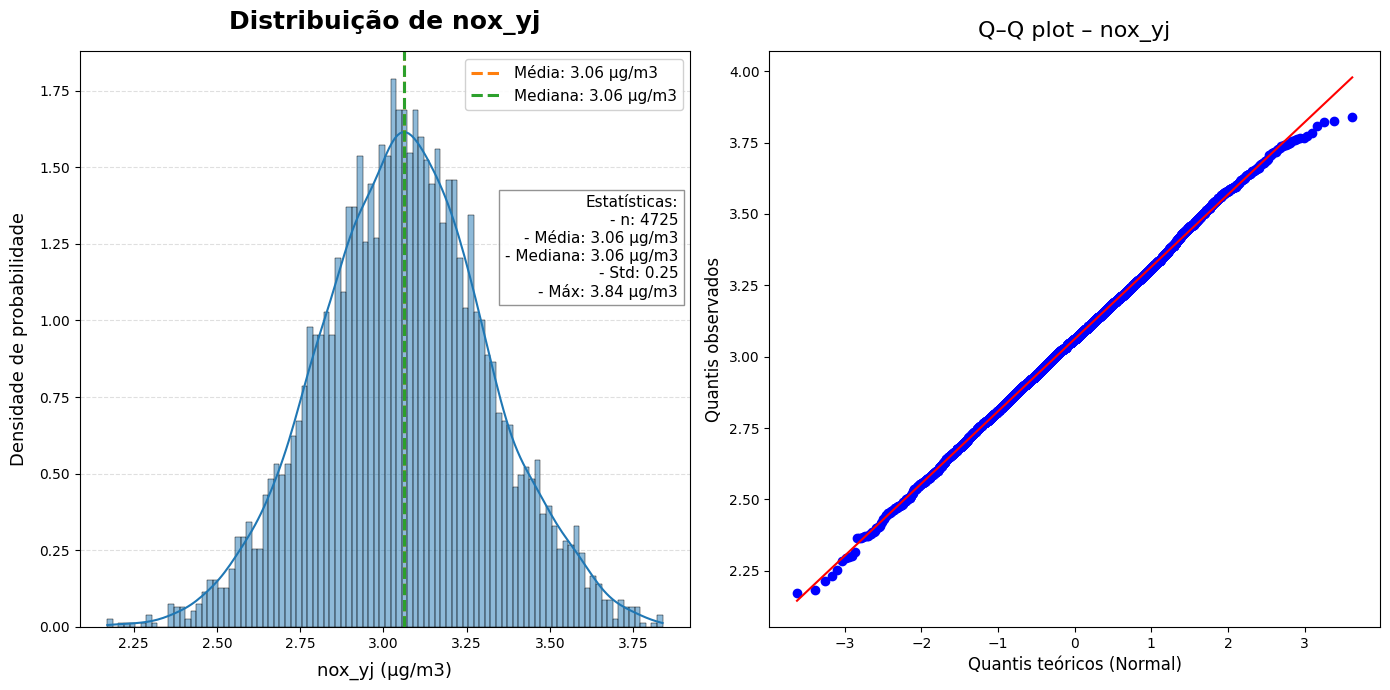

Teste de Shapiro para nox_yj: Estatística = 0.998, p-valor = 0.323
nox_yj parece seguir uma distribuição normal (p > 0.05).
p_value gerado: 0.3231832229433033

Teste de Kolmogorov-Smirnov: Estatística = 0.016, p-valor = 0.957
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.9566795163107462


In [44]:
plot_hist_qq(df_cidade, "nox_yj", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "nox_yj", sample_size=1000, seed=40)

### Dióxido de enxofre

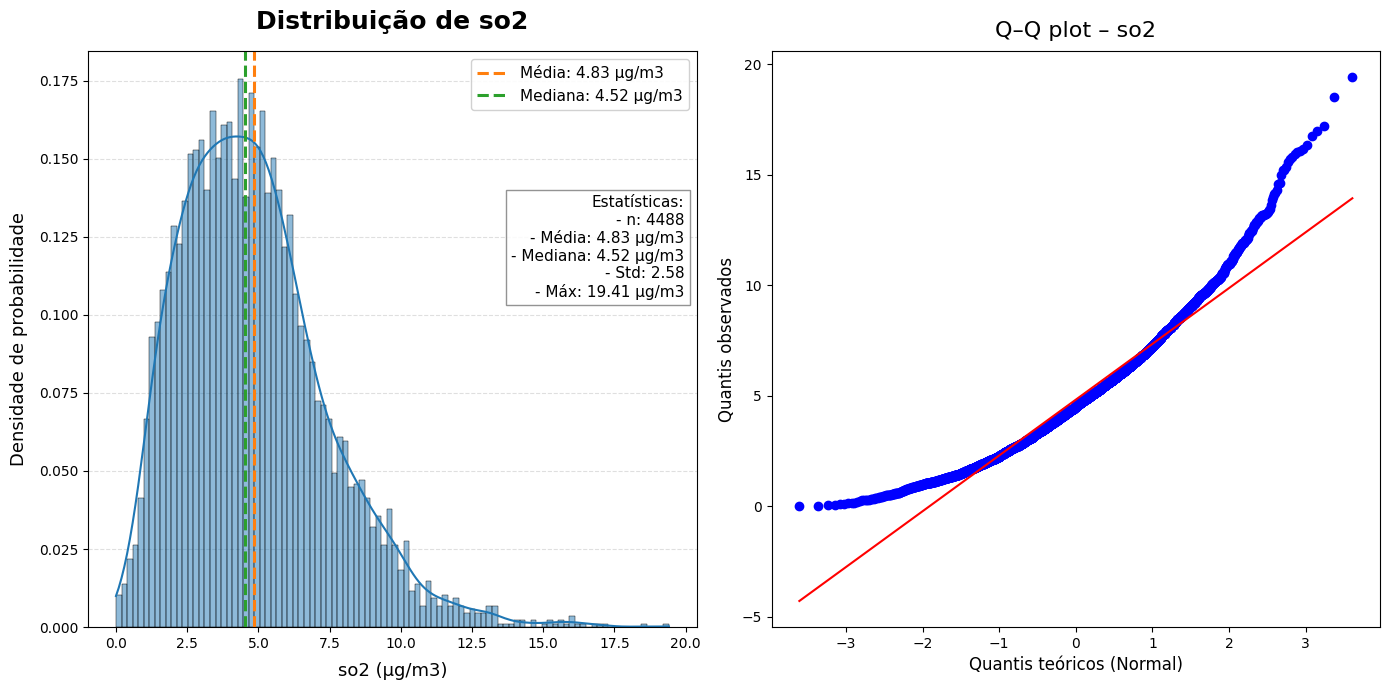

Teste de Shapiro para so2: Estatística = 0.962, p-valor = 0.000
so2 NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 1.7592215813327106e-15

Teste de Kolmogorov-Smirnov: Estatística = 0.057, p-valor = 0.003
A amostra NÃO segue uma distribuição normal.
p_value gerado: 0.002854481901197228


In [45]:
plot_hist_qq(df_cidade, "so2", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "so2", sample_size=1000, seed=40)

In [46]:
df_cidade["so2"] = pd.to_numeric(df_cidade["so2"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["so2"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
so2_vals = df_cidade.loc[mask, ["so2"]].values  
df_cidade.loc[mask, "so2_yj"] = pt.fit_transform(so2_vals).ravel()

lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'so2' com lambda = {lambda_yj:.6f}")

print(df_cidade[["so2", "so2_yj"]].head())

Yeo–Johnson aplicado em 'so2' com lambda = 0.278260
     so2    so2_yj
0  2.673  1.567692
1  1.794  1.189413
2  3.918  2.004412
3  3.124  1.736737
4  3.066  1.715770


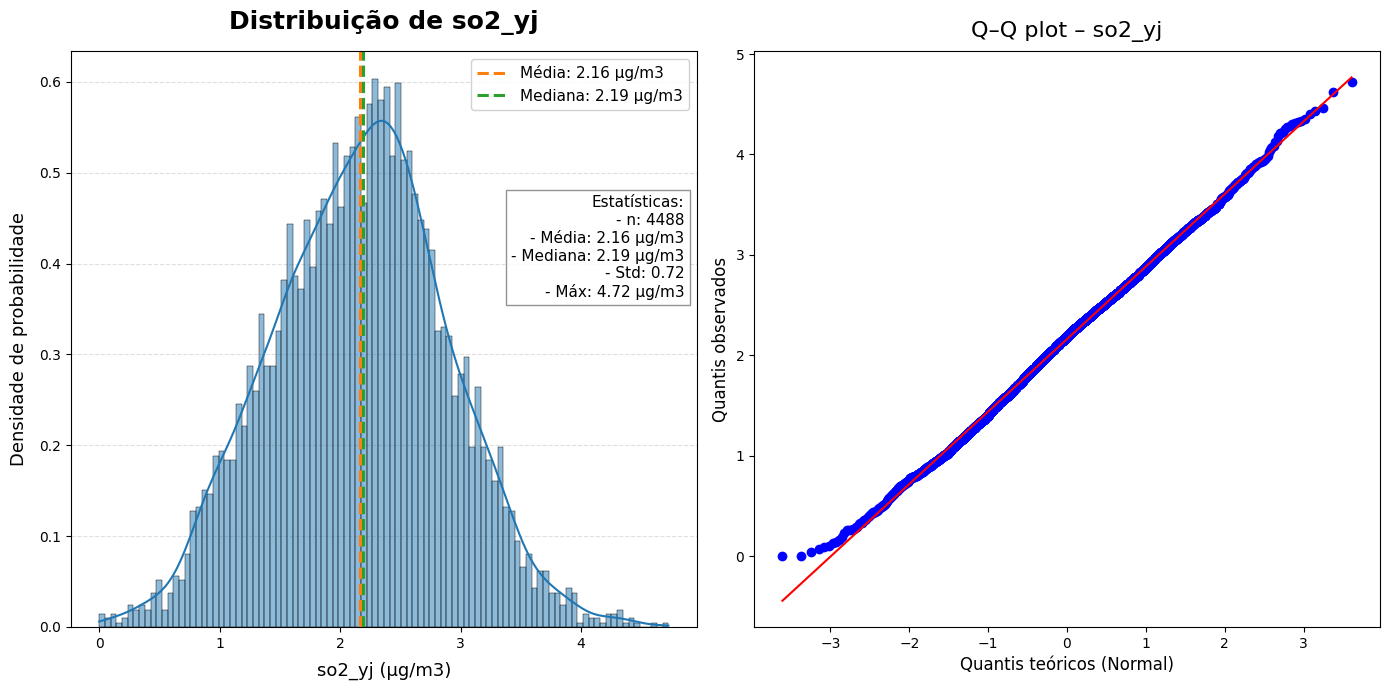

Teste de Shapiro para so2_yj: Estatística = 0.998, p-valor = 0.357
so2_yj parece seguir uma distribuição normal (p > 0.05).
p_value gerado: 0.3565240062663797

Teste de Kolmogorov-Smirnov: Estatística = 0.023, p-valor = 0.670
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.6699098149614486


In [47]:
plot_hist_qq(df_cidade, "so2_yj", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "so2_yj", sample_size=1000, seed=40)

### Ozônio

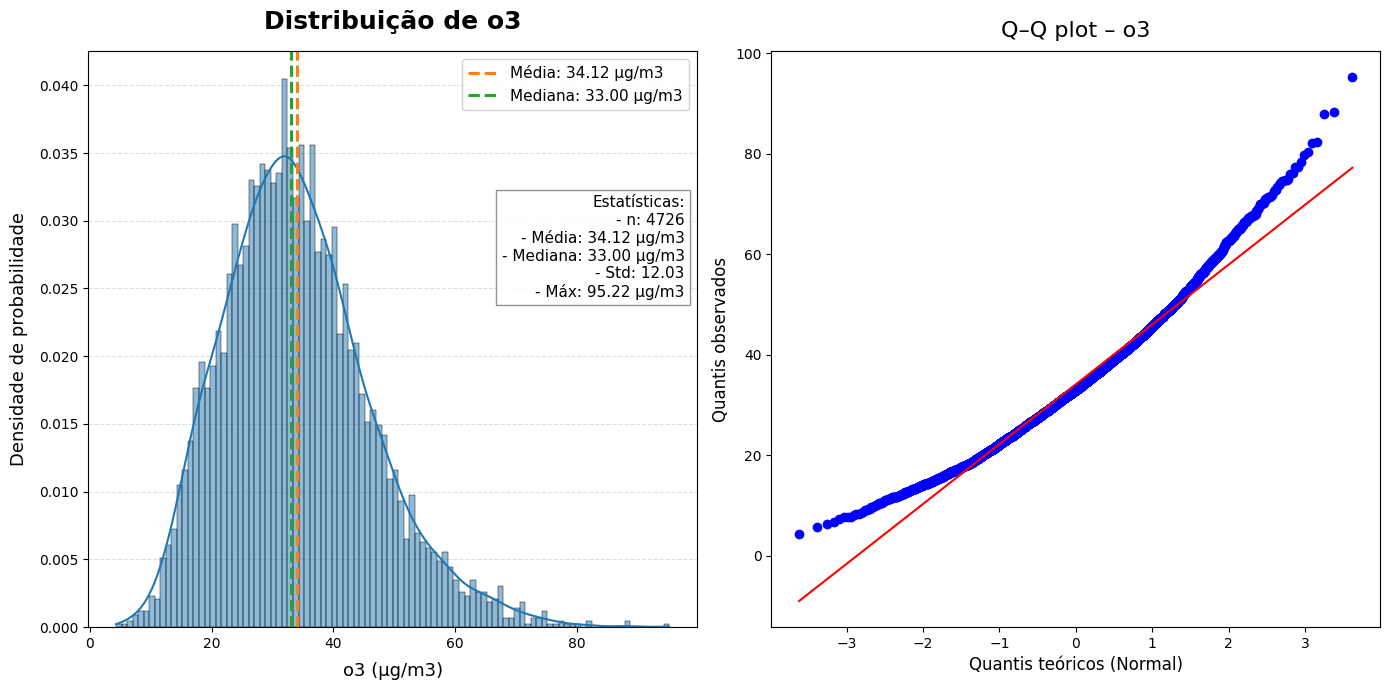

Teste de Shapiro para o3: Estatística = 0.980, p-valor = 0.000
o3 NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 1.5226170340819203e-10

Teste de Kolmogorov-Smirnov: Estatística = 0.046, p-valor = 0.030
A amostra NÃO segue uma distribuição normal.
p_value gerado: 0.030445165272352304


In [48]:
plot_hist_qq(df_cidade, "o3", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "o3", sample_size=1000, seed=40)

In [49]:
# Garante tipo numérico
df_cidade["o3"] = pd.to_numeric(df_cidade["o3"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["o3"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
o3_vals = df_cidade.loc[mask, ["o3"]].values  # 2D
df_cidade.loc[mask, "o3_yj"] = pt.fit_transform(o3_vals).ravel()

# (Opcional) guardar o lambda estimado para referência
lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'o3' com lambda = {lambda_yj:.6f}")

# Visualizar primeiras linhas
print(df_cidade[["o3", "o3_yj"]].head())

Yeo–Johnson aplicado em 'o3' com lambda = 0.403883
       o3     o3_yj
0  23.059  6.469835
1  20.136  6.013862
2  15.718  5.246714
3  25.002  6.754888
4  33.646  7.889395


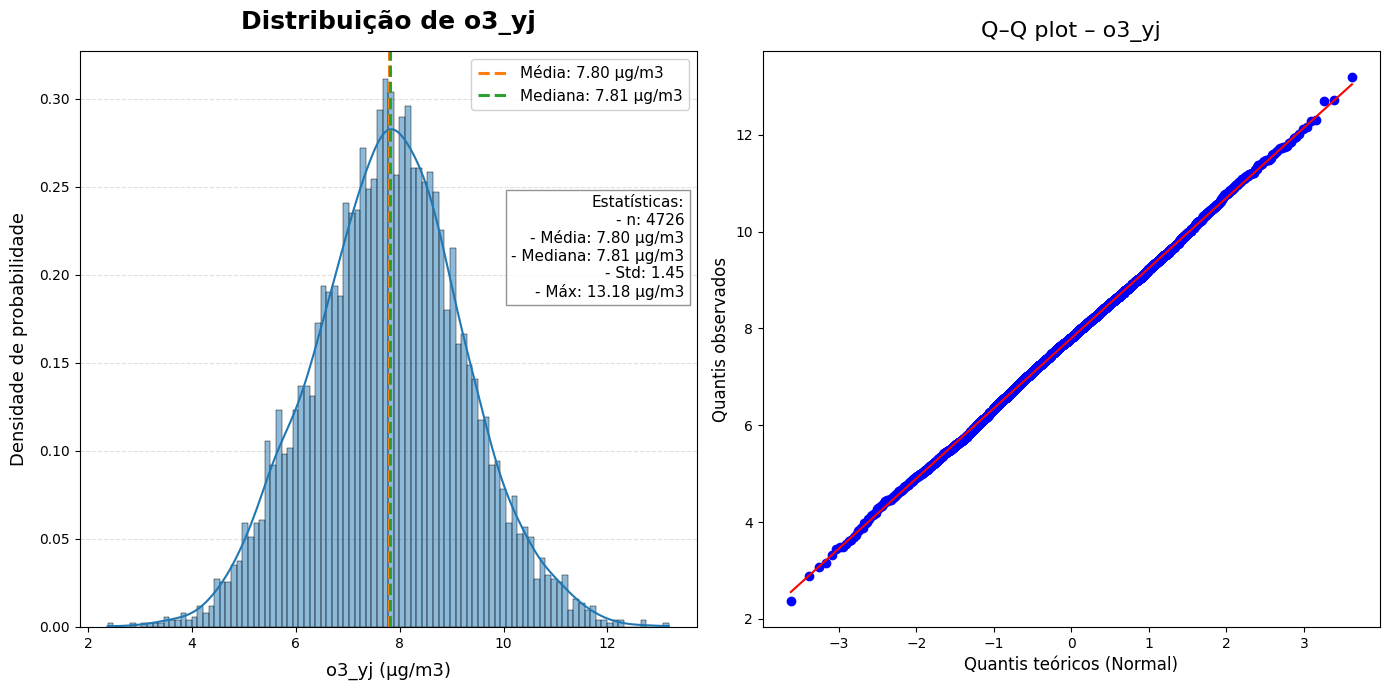

Teste de Shapiro para o3_yj: Estatística = 0.999, p-valor = 0.732
o3_yj parece seguir uma distribuição normal (p > 0.05).
p_value gerado: 0.7320903800648059

Teste de Kolmogorov-Smirnov: Estatística = 0.026, p-valor = 0.524
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.5240925391731098


In [50]:
plot_hist_qq(df_cidade, "o3_yj", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "o3_yj", sample_size=1000, seed=40)

### Matrial particular 10

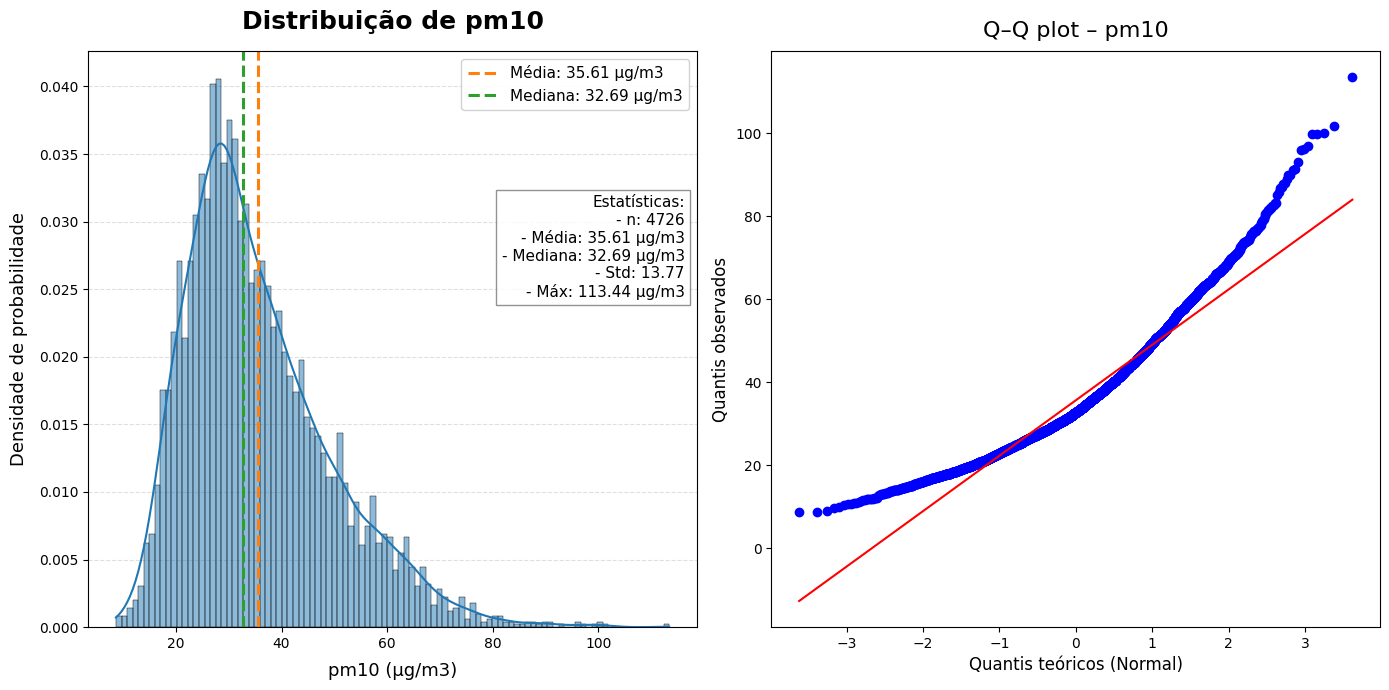

Teste de Shapiro para pm10: Estatística = 0.931, p-valor = 0.000
pm10 NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 5.168328252581465e-21

Teste de Kolmogorov-Smirnov: Estatística = 0.093, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 5.908919830506664e-08


In [51]:
plot_hist_qq(df_cidade, "pm10", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "pm10", sample_size=1000, seed=40)

In [52]:
# Garante tipo numérico
df_cidade["pm10"] = pd.to_numeric(df_cidade["pm10"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["pm10"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
pm10_vals = df_cidade.loc[mask, ["pm10"]].values  # 2D
df_cidade.loc[mask, "pm10_yj"] = pt.fit_transform(pm10_vals).ravel()

# (Opcional) guardar o lambda estimado para referência
lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'pm10' com lambda = {lambda_yj:.6f}")

# Visualizar primeiras linhas
print(df_cidade[["pm10", "pm10_yj"]].head())

Yeo–Johnson aplicado em 'pm10' com lambda = -0.040519
     pm10   pm10_yj
0  23.925  3.015162
1  13.872  2.557084
2  24.064  3.020044
3  35.773  3.353868
4  32.901  3.283483


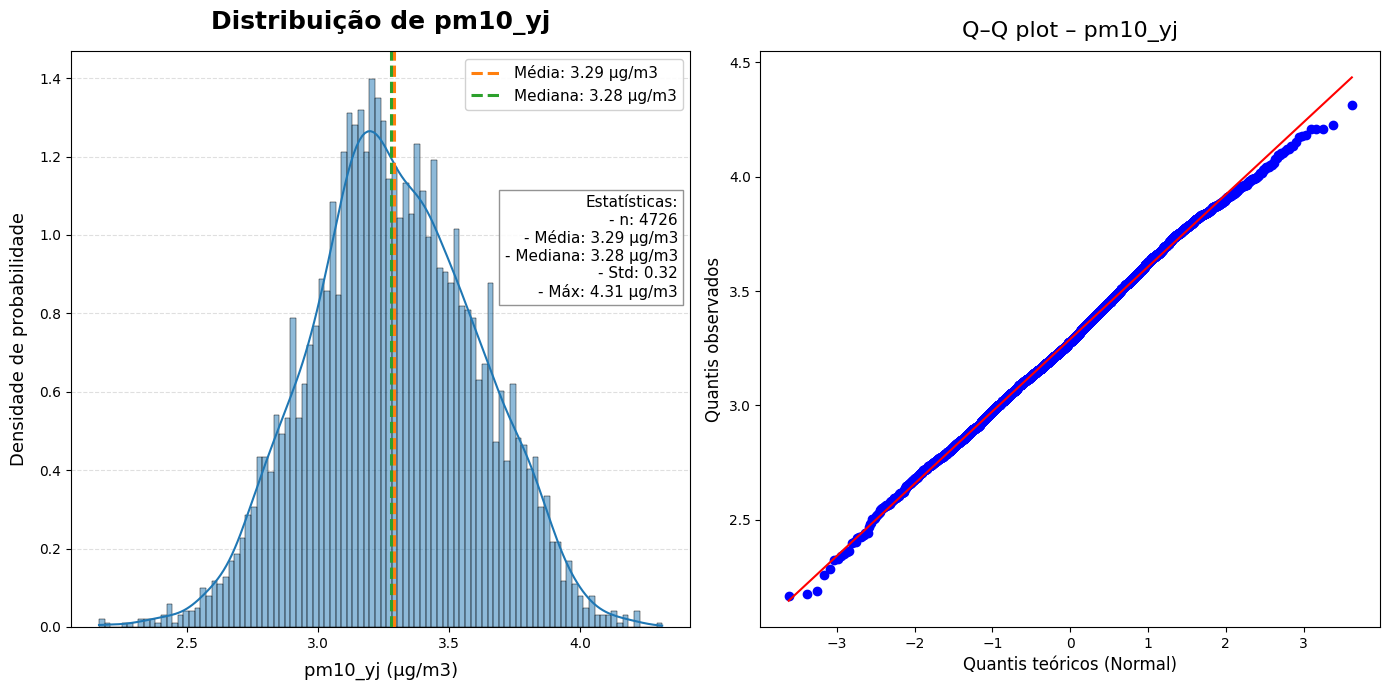

Teste de Shapiro para pm10_yj: Estatística = 0.997, p-valor = 0.041
pm10_yj NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 0.041037422902946416

Teste de Kolmogorov-Smirnov: Estatística = 0.032, p-valor = 0.237
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.23712488876342708


In [53]:
plot_hist_qq(df_cidade, "pm10_yj", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "pm10_yj", sample_size=1000, seed=40)

### Matrial particular 2.5

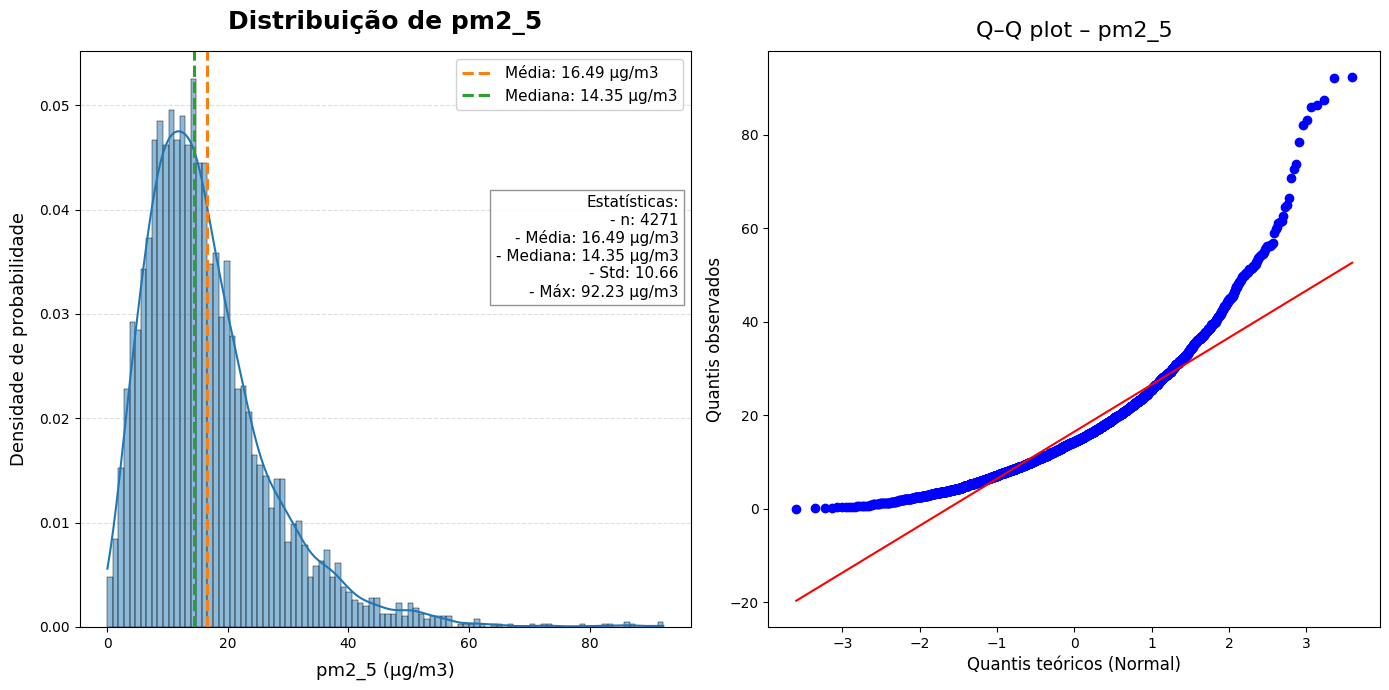

Teste de Shapiro para pm2_5: Estatística = 0.924, p-valor = 0.000
pm2_5 NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 4.272879426954569e-22

Teste de Kolmogorov-Smirnov: Estatística = 0.108, p-valor = 0.000
A amostra NÃO segue uma distribuição normal.
p_value gerado: 1.4575553972292095e-10


In [54]:
plot_hist_qq(df_cidade, "pm2_5", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "pm2_5", sample_size=1000, seed=40)

In [55]:
# Garante tipo numérico
df_cidade["pm2_5"] = pd.to_numeric(df_cidade["pm2_5"], errors="coerce")

# Máscara de valores válidos (PowerTransformer não aceita NaN)
mask = df_cidade["pm2_5"].notna()

# Instancia o transformador (sem padronizar; apenas a transformação de potência)
pt = PowerTransformer(method="yeo-johnson", standardize=False)

# Ajusta e transforma apenas os valores não nulos
pm2_5_vals = df_cidade.loc[mask, ["pm2_5"]].values  # 2D
df_cidade.loc[mask, "pm2_5_yj"] = pt.fit_transform(pm2_5_vals).ravel()

# (Opcional) guardar o lambda estimado para referência
lambda_yj = float(pt.lambdas_[0])
print(f"Yeo–Johnson aplicado em 'pm2_5' com lambda = {lambda_yj:.6f}")

# Visualizar primeiras linhas
print(df_cidade[["pm2_5", "pm2_5_yj"]].head())

Yeo–Johnson aplicado em 'pm2_5' com lambda = 0.230852
    pm2_5  pm2_5_yj
0  14.619  3.838250
1   5.083  2.239978
2   4.208  2.008542
3  15.729  3.968771
4  10.917  3.343632


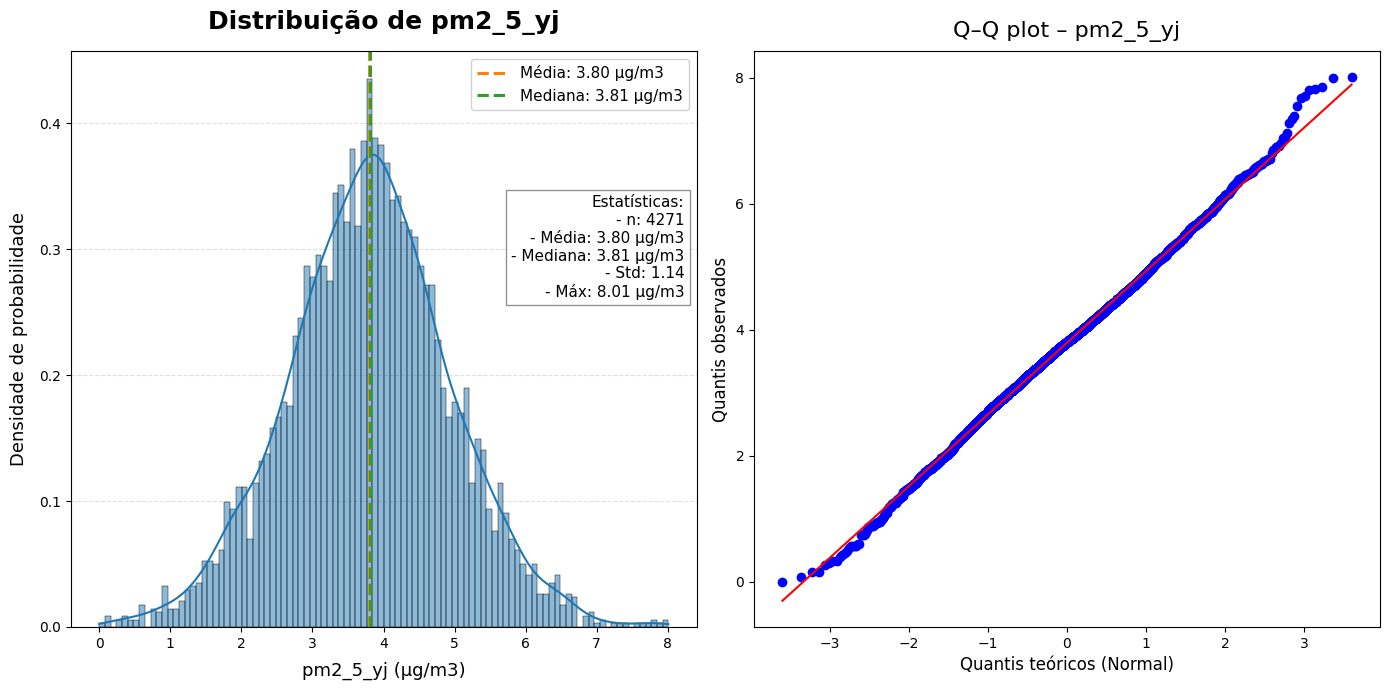

Teste de Shapiro para pm2_5_yj: Estatística = 0.996, p-valor = 0.024
pm2_5_yj NÃO segue uma distribuição normal (p <= 0.05).
p_value gerado: 0.023667998462233303

Teste de Kolmogorov-Smirnov: Estatística = 0.028, p-valor = 0.418
A amostra parece seguir uma distribuição normal.
p_value gerado: 0.41833267382510886


In [56]:
plot_hist_qq(df_cidade, "pm2_5_yj", bins=100, unit="µg/m3")
print_normality_tests(df_cidade, "pm2_5_yj", sample_size=1000, seed=40)

## Normalizando

In [57]:
orig_order = df_cidade.columns.tolist()

yj_cols = [c for c in df_cidade.columns if c.endswith('_yj')]
for yj in yj_cols:
    base = yj[:-3]  
    if base in df_cidade.columns:
        df_cidade[base] = df_cidade[yj]

df_cidade = df_cidade[[c for c in orig_order if not c.endswith('_yj')]]

display(df_cidade.head())

,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,temp_min,temp_max,AQI,Qualidade_do_Ar
0,2012-01-01,2012,1,1,0.849992,25.835,92.165,0.215703,1.256189,4.184802,2.770516,1.567692,6.469835,3.015162,3.838250,24.027,28.596,2.247600,1
1,2012-01-02,2012,1,2,0.891094,22.836,95.589,0.181572,1.884591,4.419030,3.019050,1.189413,6.013862,2.557084,2.239978,21.670,24.550,2.095642,1
2,2012-01-03,2012,1,3,0.024357,24.948,76.139,0.165267,2.021231,4.512331,3.108324,2.004412,5.246714,3.020044,2.008542,20.225,30.868,2.309268,1
3,2012-01-04,2012,1,4,0.047493,26.006,72.904,0.170964,2.175012,5.096621,3.324094,1.736737,6.754888,3.353868,3.968771,22.196,31.172,2.617709,1
4,2012-01-05,2012,1,5,-0.000000,26.498,75.514,0.169471,2.007440,4.843477,3.181217,1.715770,7.889395,3.283483,3.343632,21.994,32.466,2.660446,1


In [ ]:
# ! TEMPORATIAMENTE DESABILITADO

# cols_to_scale = ['chuva','temp','ur','co','no','no2','nox','so2','o3','pm10','pm2_5','AQI']  # sem 'Qualidade_do_Ar'
# scaler = StandardScaler()
# df_cidade[cols_to_scale] = scaler.fit_transform(df_cidade[cols_to_scale])

# display(df_cidade.head())

,data_dia,ano,mes,dia,chuva,temp,ur,co,no,no2,nox,so2,o3,pm10,pm2_5,AQI,Qualidade_do_Ar
0,2012-01-01,2012,1,1,1.693921,-0.051742,1.917484,0.693390,-1.964227,-0.759897,-1.150568,-0.822666,-0.917604,-0.869809,0.035735,-1.477106,1
1,2012-01-02,2012,1,2,1.816431,-0.943870,2.236553,-0.302832,0.226355,-0.371044,-0.168446,-1.346559,-1.232715,-2.319570,-1.367160,-2.071418,1
2,2012-01-03,2012,1,3,-0.766991,-0.315602,0.424084,-0.778747,0.702674,-0.216149,0.184335,-0.217835,-1.762871,-0.854360,-1.570305,-1.235923,1
3,2012-01-04,2012,1,4,-0.698032,-0.000874,0.122627,-0.612457,1.238748,0.753858,1.036985,-0.588549,-0.720611,0.202152,0.150301,-0.029610,1
4,2012-01-05,2012,1,5,-0.839592,0.145484,0.365842,-0.656019,0.654600,0.333601,0.472384,-0.617587,0.063417,-0.020606,-0.398419,0.137534,1


In [58]:
project_root = Path().resolve().parents[2]  

output_dir = project_root / "data" / "DataRio" 
output_dir.mkdir(parents=True, exist_ok=True)

output_csv_path = output_dir / f"QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"
df_cidade.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\data\DataRio\QUALIAR_RIO_DE_JANEIRO_TRATADO.csv
